# Rutgers SQL Data: Merging Physiological and Demographic Data

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Retrieve data exported from MySQL Workbench

**Note:** With clause hit "limits" during the joining of physiological + demographic data. exported each merged dataset to perform this in Python

**Datasets included (4/22/26):**
- BAA
- CGE
- Stress_pic
- Stress_suppl
- Stress_prevention
- VT1
- VT2
- VT3 (waiting on cohort 5 data to finish being processed)...Also, currently not in this notebook since there are only a select few HRV variables (and VT3 HRV data is already log transformed)
- WTP

Will add:
- Athlete

In [88]:
# physio_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/physio_df_clean_04232026.csv') ## old not including VT1
physio_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/Clean_scripts/B1_6P_physio_clean_04242026.csv') ## Added VT1 and WTP RRI
physio_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
0,2000,VT1,B1,689,1066,838,39,19.7,53,4.7,...,355.0,573.0,443.0,129.2,0.433,NaN,1.472700e+03,841.0,0.32,0.09
1,2000,VT1,6P,662,1207,882,93,40.5,133,10.5,...,284.0,13584.0,2638.0,514.8,0.162,NaN,1.407691e+06,902.0,0.09,0.00
2,2002,VT1,B1,673,992,850,33,10.6,57,3.9,...,655.0,709.0,230.0,308.1,0.243,NaN,4.397130e+04,853.0,0.32,0.03
3,2002,VT1,6P,617,1118,878,87,45.5,148,9.9,...,799.0,17665.0,1795.0,984.4,0.092,NaN,1.800634e+06,903.0,0.18,0.12
4,2004,VT1,B1,702,961,814,24,1.4,38,2.9,...,232.0,369.0,194.0,190.0,0.340,NaN,4.259700e+03,816.0,0.24,0.02


In [89]:
### VT1 ID6 values weren't properly added to 6-digit code for both physio and demographic data
## fixed here
vt1_mask = physio_df['from_study'] == 'VT1'

physio_df.loc[vt1_mask, 'ID6'] += 150000

In [90]:
physio_df[physio_df['from_study'] == 'VT1'].head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
0,152000,VT1,B1,689,1066,838,39,19.7,53,4.7,...,355.0,573.0,443.0,129.2,0.433,NaN,1.472700e+03,841.0,0.32,0.09
1,152000,VT1,6P,662,1207,882,93,40.5,133,10.5,...,284.0,13584.0,2638.0,514.8,0.162,NaN,1.407691e+06,902.0,0.09,0.00
2,152002,VT1,B1,673,992,850,33,10.6,57,3.9,...,655.0,709.0,230.0,308.1,0.243,NaN,4.397130e+04,853.0,0.32,0.03
3,152002,VT1,6P,617,1118,878,87,45.5,148,9.9,...,799.0,17665.0,1795.0,984.4,0.092,NaN,1.800634e+06,903.0,0.18,0.12
4,152004,VT1,B1,702,961,814,24,1.4,38,2.9,...,232.0,369.0,194.0,190.0,0.340,NaN,4.259700e+03,816.0,0.24,0.02


In [91]:
physio_df[physio_df['from_study'] == 'VT2'].head()
### Need to add the values into the participant ID to get them to merge properly

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
24,2039,VT2,B1,786,1085,950,36,15.9,52,3.8,...,988.0,467.0,377.0,123.9,0.548,0.442,NaN,953.0,0.25,0.05
25,2039,VT2,6P,703,1137,908,75,35.6,124,8.2,...,350.0,12887.0,1234.0,1044.6,0.911,0.087,NaN,925.0,0.09,0.00
26,2040,VT2,B1,720,1092,892,70,49.7,60,7.8,...,521.0,1637.0,963.0,169.9,0.622,0.366,NaN,897.0,0.32,0.04
27,2040,VT2,6P,704,1173,943,76,36.0,108,8.1,...,341.0,7895.0,1571.0,502.6,0.829,0.165,NaN,955.0,0.09,0.00
28,2042,VT2,B1,692,1052,844,51,29.3,75,6.0,...,936.0,1031.0,1794.0,57.5,0.363,0.632,NaN,850.0,0.21,0.06


In [92]:
### VT1 ID6 values weren't properly added to 6-digit code for both physio and demographic data
## fixed here
mask = physio_df['from_study'] == 'VT2'

physio_df.loc[mask, 'ID6'] += 150000
# physio_df[physio_df['from_study']=='VT2' ## looks good

In [93]:
physio_df['from_study'].unique()

array(['VT1', 'VT2', 'WTP', 'stress_pic', 'stress_suppl',
       'stress_prevention', 'BAA', 'CGE'], dtype=object)

In [94]:
physio_df[physio_df['from_study']=='VT2']
## ID6 for VT2 looks correct.

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISVlf,RRISLf,RRISHf,RRISLfHF,RRISnLf,RRISnHf,RRI,RRIWMean,RVFMean,RVFDev
24,152039,VT2,B1,786,1085,950,36,15.9,52,3.8,...,988.0,467.0,377.0,123.9,0.548,0.442,NaN,953.0,0.25,0.05
25,152039,VT2,6P,703,1137,908,75,35.6,124,8.2,...,350.0,12887.0,1234.0,1044.6,0.911,0.087,NaN,925.0,0.09,0.00
26,152040,VT2,B1,720,1092,892,70,49.7,60,7.8,...,521.0,1637.0,963.0,169.9,0.622,0.366,NaN,897.0,0.32,0.04
27,152040,VT2,6P,704,1173,943,76,36.0,108,8.1,...,341.0,7895.0,1571.0,502.6,0.829,0.165,NaN,955.0,0.09,0.00
28,152042,VT2,B1,692,1052,844,51,29.3,75,6.0,...,936.0,1031.0,1794.0,57.5,0.363,0.632,NaN,850.0,0.21,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,152124,VT2,6P,615,985,775,51,24.4,98,6.5,...,490.0,8024.0,483.0,1660.4,0.942,0.057,NaN,788.0,0.09,0.00
162,152125,VT2,B1,668,1302,795,51,27.1,59,6.4,...,963.0,838.0,633.0,132.4,0.564,0.426,NaN,799.0,0.28,0.03
163,152125,VT2,6P,549,1001,759,69,28.9,123,9.0,...,311.0,11487.0,817.0,1405.8,0.931,0.066,NaN,779.0,0.09,0.00
164,152126,VT2,B1,618,952,707,40,13.7,51,5.7,...,408.0,723.0,409.0,176.7,0.631,0.357,NaN,711.0,0.31,0.09


In [95]:
demo_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/Clean_scripts/full_demographics_04212026.csv')

demo_df.head()

,ID6,from_study,age,height,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic
0,141000,baa,21.0,NaN,NaN,NaN,F,2.0,Asian,2.0,1.0,yes
1,141001,baa,24.0,NaN,NaN,NaN,F,6.0,Other,6.0,5.0,no
2,141002,baa,25.0,NaN,NaN,NaN,F,5.0,White,5.0,5.0,no
3,141003,baa,21.0,NaN,NaN,NaN,F,2.0,Asian,2.0,1.0,yes
4,141004,baa,21.0,NaN,NaN,NaN,NaN,4.0,Native Hawaiian or Other Pacific Islander,4.0,1.0,yes


In [96]:
demo_df['from_study'].value_counts()

from_study
stress_pic           242
WTP                  175
VT3                  129
stress_prevention     97
CGE                   95
baa                   82
VT2                   81
stress_suppl          31
VT1                   24
Name: count, dtype: int64

In [97]:
demo_df[demo_df['from_study'] == 'VT2']['ID6'].head()
## matches the physio_df values for VT2, so now merges properly.

571    152039
572    152040
573    152041
574    152042
575    152043
Name: ID6, dtype: int64

## Join Physio + Demographic data

- Using LEFT JOIN onto Physio data since we are most interested in the physio data (if missing physio data, participants with only demographic data won't be included.)

In [98]:
physio_demo_df = physio_df.merge(demo_df, how = 'left', on='ID6', suffixes=['_phys', '_demo'])

physio_demo_df.rename(columns={'from_study_phys':'from_study'}, inplace=True)
physio_demo_df.drop('from_study_demo', axis=1, inplace=True)
physio_demo_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,age,height,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic
0,152000,VT1,B1,689,1066,838,39,19.7,53,4.7,...,20.0,1.80,83.7,25.83,M,NaN,NaN,NaN,NaN,NaN
1,152000,VT1,6P,662,1207,882,93,40.5,133,10.5,...,20.0,1.80,83.7,25.83,M,NaN,NaN,NaN,NaN,NaN
2,152002,VT1,B1,673,992,850,33,10.6,57,3.9,...,20.0,1.65,64.3,23.62,M,NaN,NaN,NaN,NaN,NaN
3,152002,VT1,6P,617,1118,878,87,45.5,148,9.9,...,20.0,1.65,64.3,23.62,M,NaN,NaN,NaN,NaN,NaN
4,152004,VT1,B1,702,961,814,24,1.4,38,2.9,...,22.0,1.77,78.6,25.09,M,NaN,NaN,NaN,NaN,NaN


## Exploratory Data Analysis of full dataset

### Counts of data distribution

- number of participants from each study DB
- count of participants with full and partial demographic data (H+W, race + ethnicity)

In [99]:
## Quick count of participants by study and timepoint get get a snapshot of the data distribution across studies and timepoints.
physio_demo_df.groupby('from_study', as_index=False, observed=True)['timepoint'].value_counts()

,from_study,timepoint,count
0,BAA,6P,70
1,BAA,B1,70
2,CGE,6P,51
3,CGE,B1,51
4,VT1,6P,12
5,VT1,B1,12
6,VT2,6P,71
7,VT2,B1,71
8,WTP,6P,178
9,WTP,B1,178


In [100]:
physio_demo_df['ID6'].nunique() ## 150 unique participants in the merged dataset, which is correct (75 VT1 + 75 VT2)

585

In [101]:
physio_demo_df.shape
## Rows, columns 

(1348, 36)

In [102]:
missing_values_df = pd.DataFrame({
    'count': physio_demo_df.isnull().sum(),
    'percent_missing': (physio_demo_df.isnull().sum() / len(physio_demo_df)) * 100 
}).sort_values(by='percent_missing', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(missing_values_df[missing_values_df['percent_missing'] > 0])

               column  count  percent_missing
0                 RRI   1146            85.01
1              height    498            36.94
2                 bmi    498            36.94
3              weight    498            36.94
4            RRIWMean    394            29.23
5            hispanic     54             4.01
6                race     52             3.86
7           race_text     52             3.86
8   race_code_cleaned     52             3.86
9           ethnicity     50             3.71
10                age     22             1.63
11            RRISnHf     15             1.11
12                sex     12             0.89


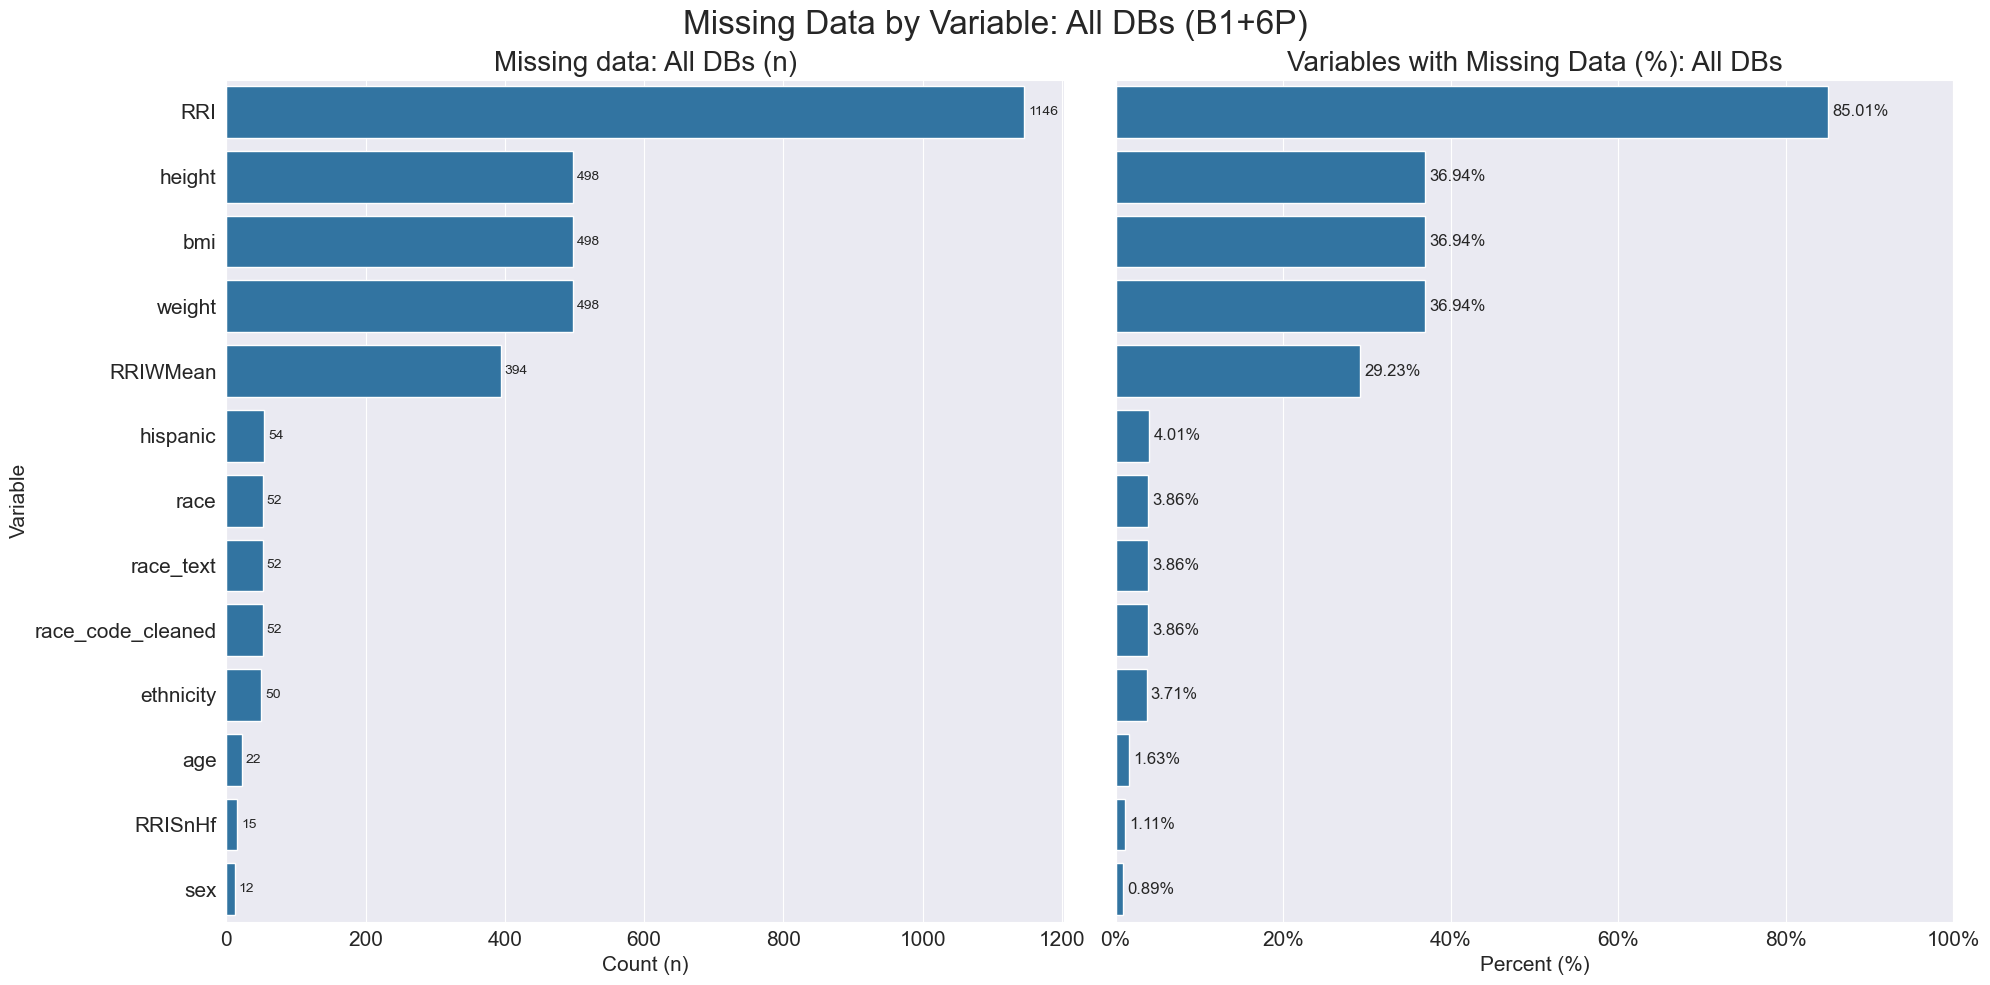

In [103]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(20,10))

### Filter_df to only include variables with missing data for better visualization
filtered_df = missing_values_df[missing_values_df['percent_missing'] > 0].copy().reset_index(drop=True)

ax1= sns.barplot(y=filtered_df['column'], x=filtered_df['count'], ax=ax[0])

ax1.set_ylabel('Variable',fontsize=15)
ax1.set_xlabel('Count (n)',fontsize=15)
# ax1.tick_params(axis='x', rotation=-90)
ax1.bar_label(ax1.containers[0], fmt='%.0f', padding=3)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_title('Missing data: All DBs (n)', fontsize=20)

#### Second Plot 
ax2= sns.barplot(y=filtered_df['column'], x=filtered_df['percent_missing'], ax=ax[1])

ax2.set_ylabel('Variable', fontsize=15)
ax2.set_xlabel('Percent (%)',fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.bar_label(ax2.containers[0], fmt='%.2f%%', padding=3, fontsize=12)
ax2.set_title('Missing data: All DBs (n)', fontsize=20)
ax2.set_title('Variables with Missing Data (%): All DBs', fontsize=20)

fig.suptitle('Missing Data by Variable: All DBs (B1+6P)', fontsize=24)

plt.tight_layout()
plt.show()

### Adding BMI and BMI categories

- Ranges and terms from CDC

In [104]:
physio_demo_df['bmi_cat'] = physio_demo_df['bmi'].apply(lambda x:
                                                        'Underweight' if x < 18.5 else
                                                        'Healthy weight' if 18.5 <= x < 25 else
                                                        'Overweight' if 25 <= x < 30 else
                                                        'Obese' if x >= 30 else
                                                        np.nan
                                                        )
physio_demo_df['bmi_code_cat'] = physio_demo_df['bmi'].apply(lambda x:
                                                        '1' if x < 18.5 else
                                                        '2' if 18.5 <= x < 25 else
                                                        '3' if 25 <= x < 30 else
                                                        '4' if 30 >= x else
                                                        np.nan
                                                        )
physio_demo_df['bmi_cat'] = pd.Categorical(physio_demo_df['bmi_cat'], categories=['Healthy weight', 'Underweight', 'Overweight', 'Obese'], ordered=True)

physio_demo_df[['ID6', 'from_study', 'bmi', 'bmi_cat', 'bmi_code_cat']].head()


,ID6,from_study,bmi,bmi_cat,bmi_code_cat
0,152000,VT1,25.83,Overweight,3
1,152000,VT1,25.83,Overweight,3
2,152002,VT1,23.62,Healthy weight,2
3,152002,VT1,23.62,Healthy weight,2
4,152004,VT1,25.09,Overweight,3


In [105]:
## Original in case I mess up 

# physio_demo_df['bmi_cat'] = physio_demo_df['bmi'].apply(lambda x:
#                                                         'Underweight' if x < 18.5 else
#                                                         'Healthy weight' if 18.5 <= x < 25 else
#                                                         'Overweight' if 25 <= x < 30 else
#                                                         # 'Obese' if x >= 30 else
#                                                         'Obesity_1' if 30 <= x < 35 else
#                                                         'Obesity_2' if 35 <= x < 40 else
#                                                         'Obesity_3' if x >= 40 else
#                                                         np.nan
#                                                         )
# physio_demo_df['bmi_code_cat'] = physio_demo_df['bmi'].apply(lambda x:
#                                                         '1' if x < 18.5 else
#                                                         '2' if 18.5 <= x < 25 else
#                                                         '3' if 25 <= x < 30 else
#                                                         # 'Obese' if x >= 30 else
#                                                         '4' if 30 <= x < 35 else
#                                                         '5' if 35 <= x < 40 else
#                                                         '6' if x >= 40 else
#                                                         np.nan
#                                                         )
# physio_demo_df['bmi_cat'] = pd.Categorical(physio_demo_df['bmi_cat'], categories=['Underweight', 'Healthy weight', 'Overweight', 'Obesity_1', 'Obesity_2', 'Obesity_3'], ordered=True)

# physio_demo_df[['ID6', 'from_study', 'bmi', 'bmi_cat', 'bmi_code_cat']].head()


In [106]:
bmi_df = physio_demo_df.groupby('bmi_cat', as_index=False, observed=False)['ID6'].count().rename(columns={'ID6': 'count'})

bmi_df['percent'] = ((bmi_df['count'] / bmi_df['count'].sum()) * 100).round(2)

bmi_df

,bmi_cat,count,percent
0,Healthy weight,454,53.41
1,Underweight,26,3.06
2,Overweight,242,28.47
3,Obese,128,15.06


In [107]:
physio_demo_df['bmi_cat'].dtype

CategoricalDtype(categories=['Healthy weight', 'Underweight', 'Overweight', 'Obese'], ordered=True, categories_dtype=object)

In [108]:
# physio_demo_df['bmi_cat'].replace({'Obesity_1': 'Obese', 'Obesity_2':'Obese', 'Obesity_3':'Obese'}, inplace=True)

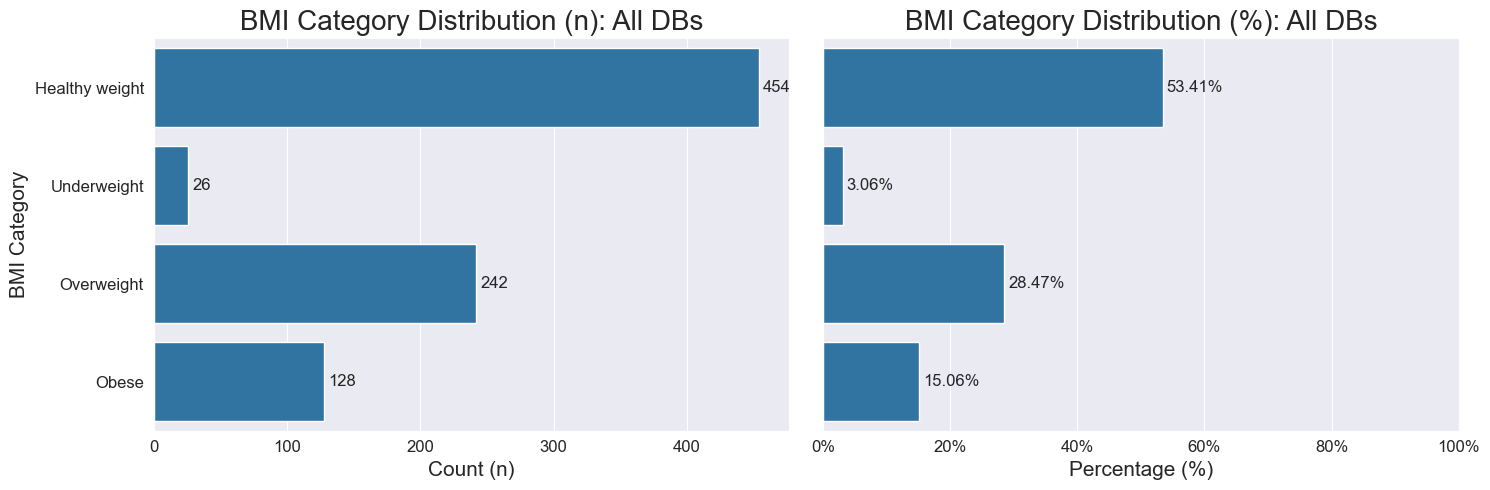

In [109]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(15,5))

ax1 = sns.barplot(data=bmi_df, y='bmi_cat', x='count', ax=ax[0])

ax1.bar_label(ax1.containers[0], label_type= 'edge', padding=3, fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_ylabel('BMI Category', fontsize=15)
ax1.set_xlabel('Count (n)', fontsize=15)
ax1.set_title('BMI Category Distribution (n): All DBs', fontsize=20)

# ax1.set_yticklabels([''], fontsize=12)

#### Second Plot
ax2 = sns.barplot(data=bmi_df, y='bmi_cat', x='percent', ax=ax[1])

ax2.bar_label(ax2.containers[0], fmt = '%.2f%%',
              label_type= 'edge', padding=3, fontsize=12)

ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_xlabel('Percentage (%)', fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=[f'{i}%' for i in np.arange(0,101,20)])
ax2.set_title('BMI Category Distribution (%): All DBs', fontsize=20)

plt.tight_layout()

plt.show()

In [110]:
## Making a list of demographic variables for later use

demographic_variables = list(['sex',
                        'bmi_cat',
                         'race',
                         'race_text',
                         'ethnicity',
                         'hispanic']
)

demographic_variables

['sex', 'bmi_cat', 'race', 'race_text', 'ethnicity', 'hispanic']

In [111]:
physio_demo_df[demographic_variables] = physio_demo_df[demographic_variables].astype('category')
physio_demo_df[['from_study', 'timepoint']] = physio_demo_df[['from_study', 'timepoint']].astype('category')

In [112]:
physio_demo_df[demographic_variables].dtypes

sex          category
bmi_cat      category
race         category
race_text    category
ethnicity    category
hispanic     category
dtype: object

### Making subsets of data based on demographic variable completeness.

In [113]:
print("Potential Dataset options for physiological + demographic variables:")
print(f"This dataset includes {physio_demo_df['ID6'].nunique()} unique participants, regardless of demographic data.")

full_rows_df = physio_demo_df.dropna(subset=demographic_variables, axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with complete demographic data (age, height, weight, sex, race, ethnicity, hispanic) at baseline (B1).")

full_rows_df = physio_demo_df.dropna(subset=['age'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with complete age demographic data at baseline (B1).") ## missing 10 age values at B1

full_rows_df = physio_demo_df.dropna(subset=['age', 'height', 'weight'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with age + height + weight data at baseline (B1).")

full_rows_df = physio_demo_df.dropna(subset=['age', 'race', 'ethnicity'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with age + race + ethnicity data at baseline (B1).")

Potential Dataset options for physiological + demographic variables:
This dataset includes 585 unique participants, regardless of demographic data.
There are 321 unique participants with complete demographic data (age, height, weight, sex, race, ethnicity, hispanic) at baseline (B1).
There are 575 unique participants with complete age demographic data at baseline (B1).
There are 337 unique participants with age + height + weight data at baseline (B1).
There are 558 unique participants with age + race + ethnicity data at baseline (B1).


In [114]:
full_rows_b1_df.groupby('from_study', as_index=False, observed=True)['ID6'].nunique().rename(columns={'ID6': 'Count (n)'})

,from_study,Count (n)
0,BAA,65
1,CGE,47
2,VT2,68
3,WTP,88
4,stress_pic,165
5,stress_prevention,94
6,stress_suppl,31


In [115]:
## What is still missing from "full demographics rows" at B1 timepoint
missing_table = pd.DataFrame({
    'variable': full_rows_b1_df.columns,
    'missing_count': full_rows_b1_df.isna().sum(),
    'percent_missing': ((full_rows_b1_df.isna().sum() / len(full_rows_b1_df)) * 100).round(2)

}).reset_index(drop=True).sort_values(by='percent_missing', ascending=False)

missing_table[missing_table['percent_missing'] > 0]

,variable,missing_count,percent_missing
23,RRI,558,86.38
38,bmi_code_cat,301,46.59
29,weight,237,36.69
28,height,237,36.69
30,bmi,237,36.69
37,bmi_cat,237,36.69
24,RRIWMean,196,30.34
36,hispanic,2,0.31
22,RRISnHf,1,0.15


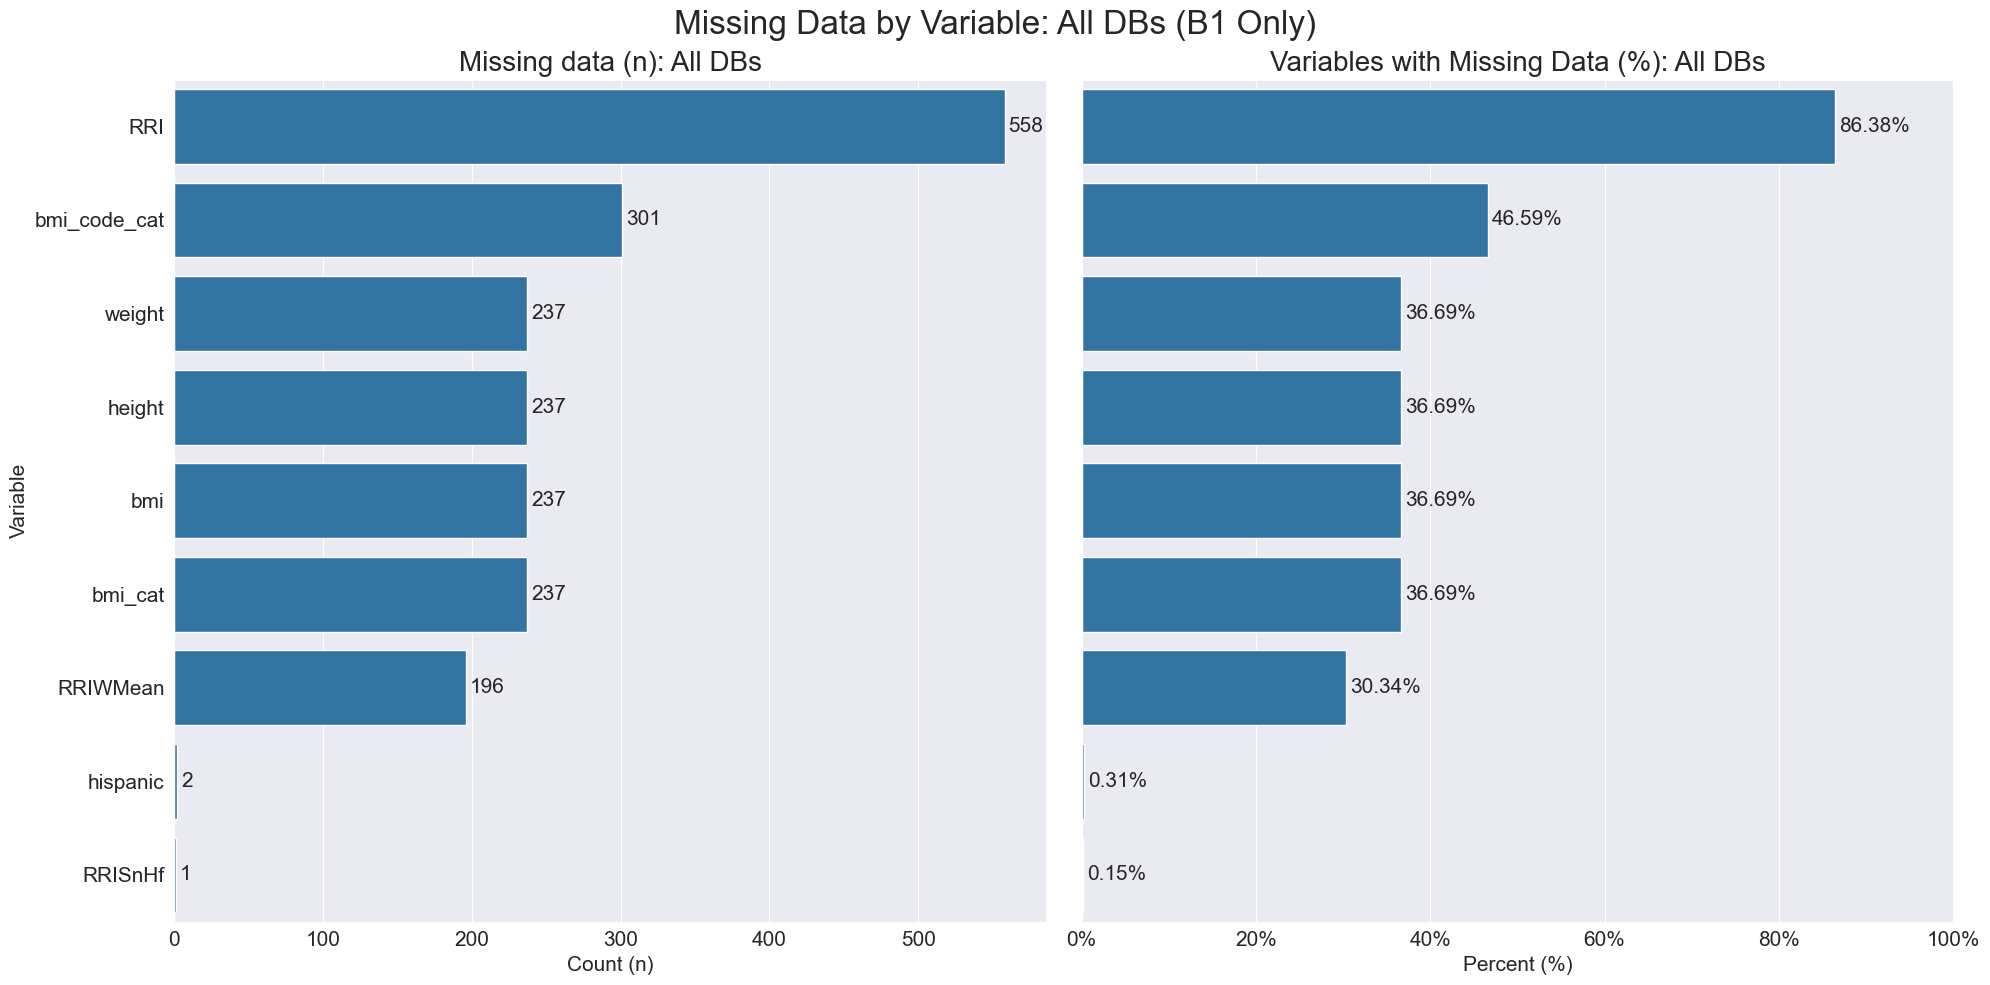

In [116]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(20,10))

### Filter_df to only include variables with missing data for better visualization
filtered_df = missing_table[missing_table['percent_missing'] > 0].copy().reset_index(drop=True)

ax1= sns.barplot(y=filtered_df['variable'], x=filtered_df['missing_count'], ax=ax[0])

ax1.set_ylabel('Variable',fontsize=15)
ax1.set_xlabel('Count (n)',fontsize=15)
# ax1.tick_params(axis='x', rotation=-90)
ax1.bar_label(ax1.containers[0], fmt='%.0f', padding=3, fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_title('Missing data (n): All DBs', fontsize=20)

#### Second Plot 
ax2= sns.barplot(y=filtered_df['variable'], x=filtered_df['percent_missing'], ax=ax[1])

ax2.set_ylabel('Variable', fontsize=15)
ax2.set_xlabel('Percent (%)',fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.bar_label(ax2.containers[0], fmt='%.2f%%', padding=3, fontsize=15)
ax2.set_title('Missing data: All DBs (n)', fontsize=20)
ax2.set_title('Variables with Missing Data (%): All DBs', fontsize=20)

fig.suptitle('Missing Data by Variable: All DBs (B1 Only)', fontsize=24)

plt.tight_layout()
plt.show()

### Demographics breakdown at baseline

In [117]:
physio_demo_df_B1 = physio_demo_df[physio_demo_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

physio_demo_df_B1.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,152000,VT1,B1,689,1066,838,39,19.7,53,4.7,...,83.7,25.83,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
1,152002,VT1,B1,673,992,850,33,10.6,57,3.9,...,64.3,23.62,M,NaN,NaN,NaN,NaN,NaN,Healthy weight,2
2,152004,VT1,B1,702,961,814,24,1.4,38,2.9,...,78.6,25.09,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
3,152006,VT1,B1,620,829,707,20,2.1,35,2.9,...,81.5,29.22,M,NaN,NaN,NaN,NaN,NaN,Overweight,3
4,152008,VT1,B1,725,1052,918,29,8.0,51,3.2,...,64.3,20.29,M,NaN,NaN,NaN,NaN,NaN,Healthy weight,2


### Participant retention from each study 

- Check to see count (n) of participants in MySQL databases, compared to count of participants found in Python after the physio + demographics dfs merge. 
- Difference = the n number of participants lost from data transferrance (incomplete data). I performed a LEFT JOIN to join demographic data onto the physiological data...If we didn't have an individual's physiological data, we weren't going to use them in the data analysis.

In [118]:
## Checking to see how many participants (n) made it from MySQL server to fully merged df at B1 timepoint, by study

study_count_df = physio_demo_df_B1.groupby('from_study', as_index=False, observed=True)['ID6'].nunique().rename(columns={'ID6': 'Count (n)'})

# study_count_df['SQL_count'] = []

study_names = {'BAA': 71, # BAA
'CGE': 90, # CGE
'VT1': 12, # VT1
'VT2': 71, # VT2
'WTP': 89, # WTP
'stress_pic': 166, # stress_pic
'stress_prevention': 95,
'stress_suppl': 31
## VT3 Here
## Athlete Here
}

study_count_df['SQL_count'] = study_count_df['from_study'].map(study_names)
study_count_df['n_lost'] = study_count_df['SQL_count'] - study_count_df['Count (n)']

print(study_count_df)

          from_study  Count (n)  SQL_count  n_lost
0                BAA         70         71       1
1                CGE         51         90      39
2                VT1         12         12       0
3                VT2         71         71       0
4                WTP         89         89       0
5         stress_pic        166        166       0
6  stress_prevention         95         95       0
7       stress_suppl         31         31       0


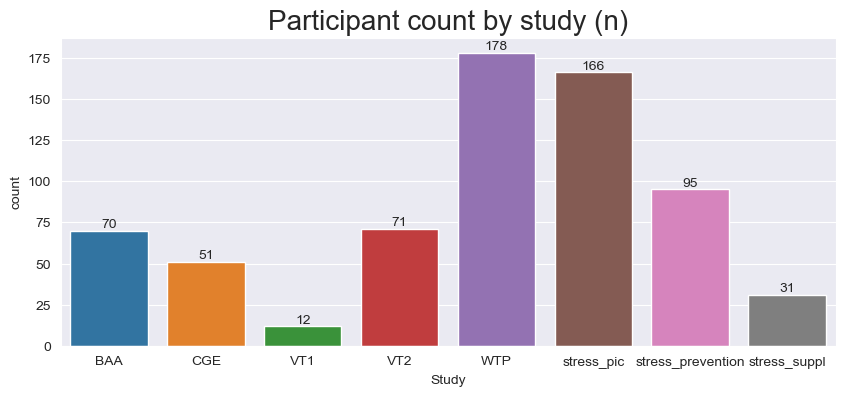

In [119]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.countplot(data=physio_demo_df_B1, x='from_study', hue='from_study')

for container in ax1.containers:
    ax1.bar_label(container, fontsize=10)

plt.title('Participant count by study (n)', fontsize=20)
plt.xlabel('Study')
plt.show()

### Age

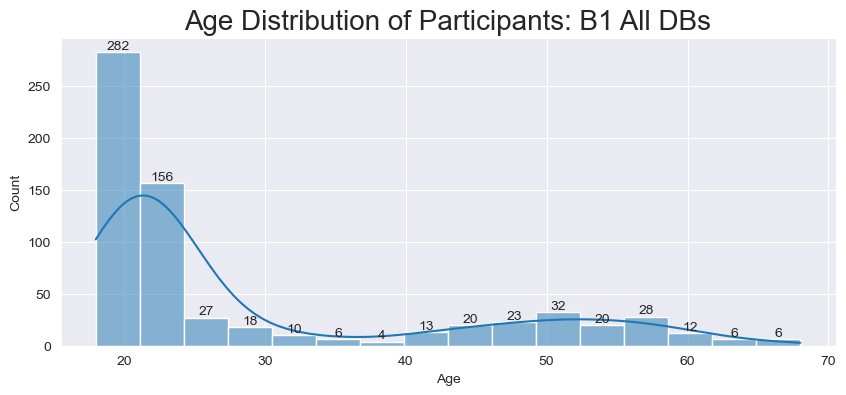

In [120]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age', kde=True)

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: B1 All DBs', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

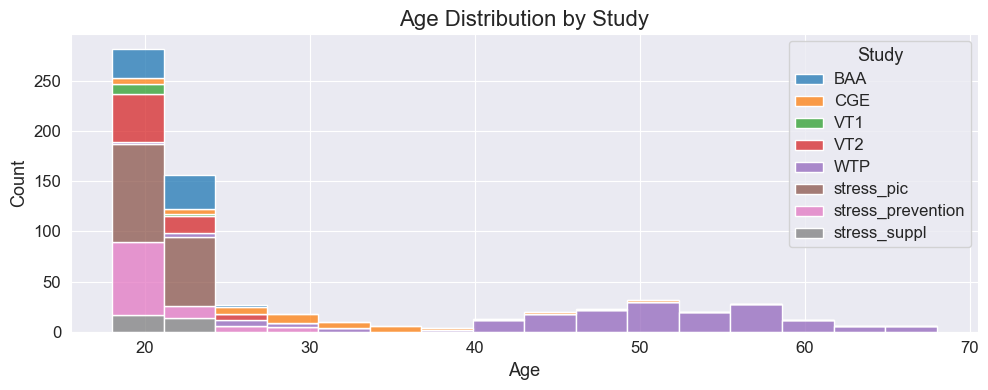

In [121]:
fig, ax = plt.subplots(figsize=(10, 4))

ax1 = sns.histplot(
    data=physio_demo_df_B1,
    x='age',
    hue='from_study',
    multiple='stack'
)

legend = ax1.get_legend()
legend.set_title('Study')
legend.get_title().set_fontsize(13)
for text in legend.get_texts():
    text.set_fontsize(12)

ax1.set_xlabel('Age', fontsize=13)
ax1.set_ylabel('Count', fontsize=13)
ax1.set_title('Age Distribution by Study', fontsize=16)
ax1.tick_params(axis='both', labelsize=12)


plt.tight_layout()
plt.show()

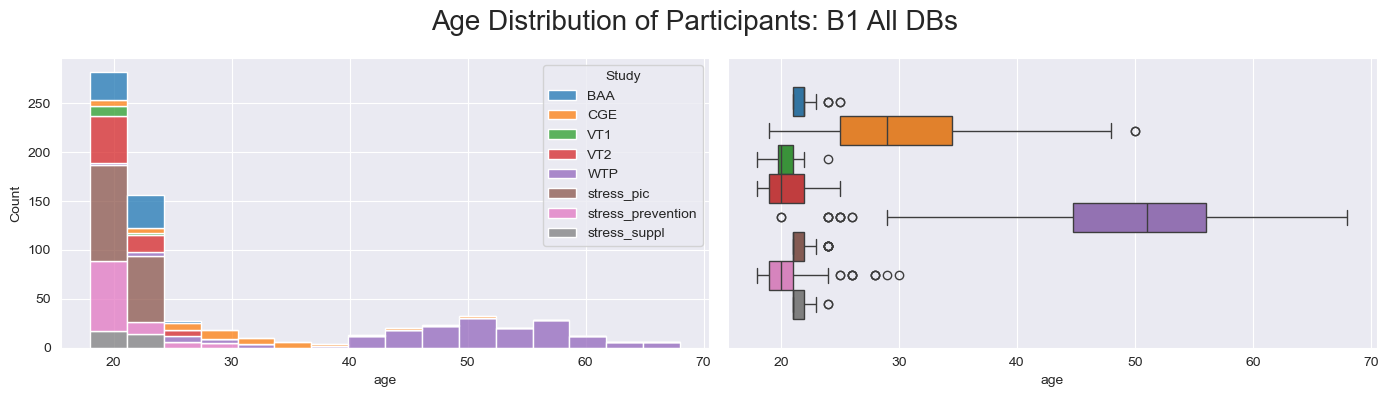

In [122]:
fig, ax = plt.subplots(1,2, figsize=(14,4))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age', hue='from_study', multiple='stack',ax=ax[0])
ax1.get_legend().set_title('Study')

##### second plot
ax2 = sns.boxplot(data= physio_demo_df_B1, x='age', hue='from_study', ax=ax[1])

ax2.get_legend().remove()

plt.suptitle('Age Distribution of Participants: B1 All DBs', fontsize=20)
plt.tight_layout()

plt.show()

### Race

In [123]:
race_df = physio_demo_df_B1.groupby(['race_text']).size().reset_index(name='count')

race_df['percentage'] = (race_df['count']/ race_df['count'].sum()*100).round(2)

race_df = race_df.sort_values(by='percentage', ascending=False)

race_df

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_98948/2899392366.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_df = physio_demo_df_B1.groupby(['race_text']).size().reset_index(name='count')


,race_text,count,percentage
5,White,467,72.07
1,Asian,83,12.81
2,Black or African American,51,7.87
4,Other,35,5.40
3,Native Hawaiian or Other Pacific Islander,9,1.39
0,American Indian or Alaska Native,3,0.46


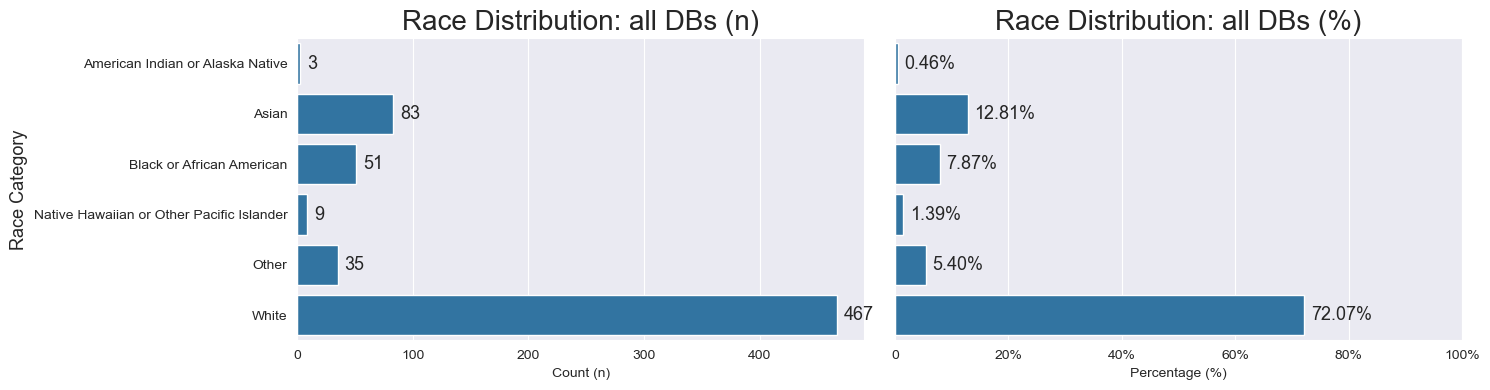

In [124]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,4))

ax1 = sns.barplot(data=race_df, x='count', y='race_text', ax=ax[0])

ax1.set_xlabel('Count (n)')
ax1.set_title('Race Distribution: all DBs (n)', fontsize=20)
ax1.bar_label(ax1.containers[0], fontsize=13, padding=5),
ax1.set_ylabel('Race Category', fontsize=13)

#### second plot
ax2 = sns.barplot(data=race_df, x='percentage', y='race_text', ax=ax[1])

ax2.set_xlabel('Percentage (%)')
ax2.set_title('Race Distribution: all DBs (%)', fontsize=20)
for container in ax2.containers:
    ax2.bar_label(container, labels=[f'{v.get_width():0.2f}%' for v in container], fontsize=13, padding=5)
ax2.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])

plt.tight_layout()
plt.show()

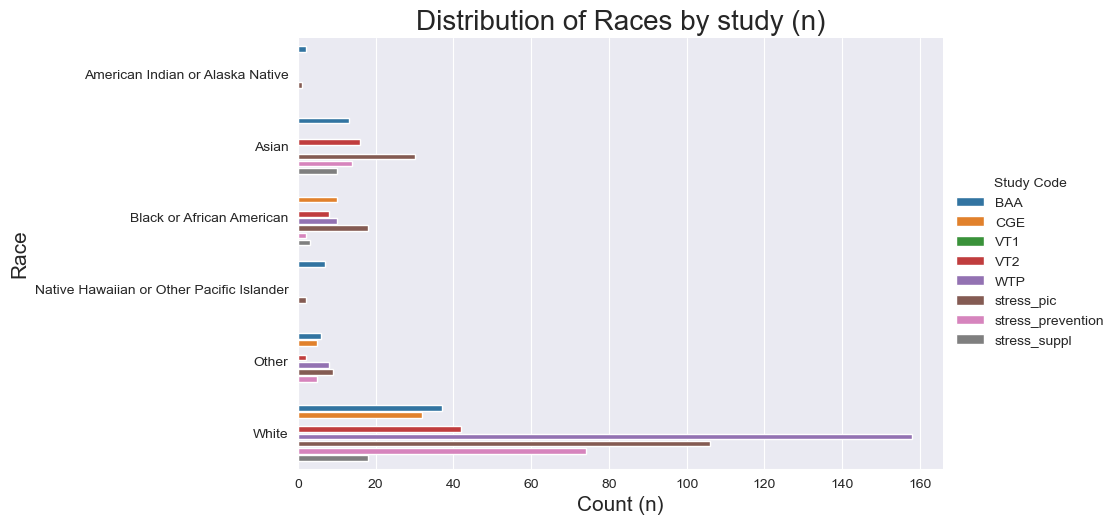

In [125]:
ax1 = sns.catplot(data= physio_demo_df_B1, y='race_text', hue='from_study', kind='count',
                 height= 5,
                 aspect = 2,
                 gap=0.2
)

plt.title('Distribution of Races by study (n)', fontsize=20)
ax1.legend.set_title('Study Code')
ax1.set_axis_labels('Count (n)', 'Race', fontsize=15)
    
plt.show()

### Sex

In [126]:
sex_df = physio_demo_df_B1.groupby(['sex'], observed=True).size().reset_index(name='count')

sex_df['percentage'] = ((sex_df['count'] / sex_df['count'].sum())*100).round(2)

sex_df

,sex,count,percentage
0,F,446,66.77
1,M,222,33.23


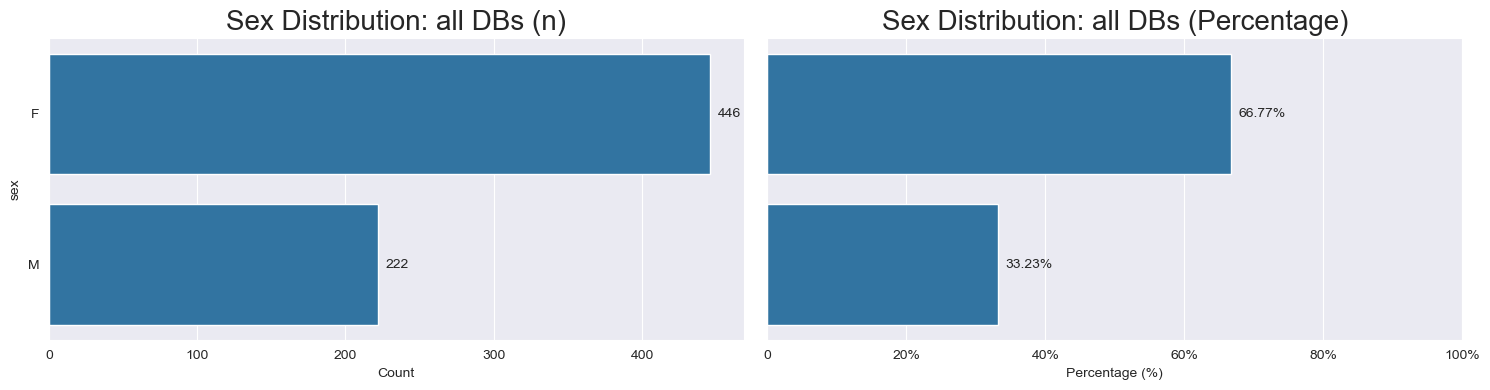

In [127]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,4))

ax1 = sns.barplot(data=sex_df, x='count', y='sex', ax=ax[0])

ax1.set_xlabel('Count')
ax1.set_title('Sex Distribution: all DBs (n)', fontsize=20)
ax1.bar_label(ax1.containers[0], fontsize=10, padding=5),

# ax1.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])


ax2 = sns.barplot(data=sex_df, x='percentage', y='sex', ax=ax[1])

ax2.set_xlabel('Percentage (%)')
ax2.set_title('Sex Distribution: all DBs (Percentage)', fontsize=20)

for container in ax2.containers:
    ax2.bar_label(container, labels=[f'{v.get_width():.2f}%' for v in container], fontsize=10, padding= 5)


ax2.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])
plt.tight_layout()
plt.show()

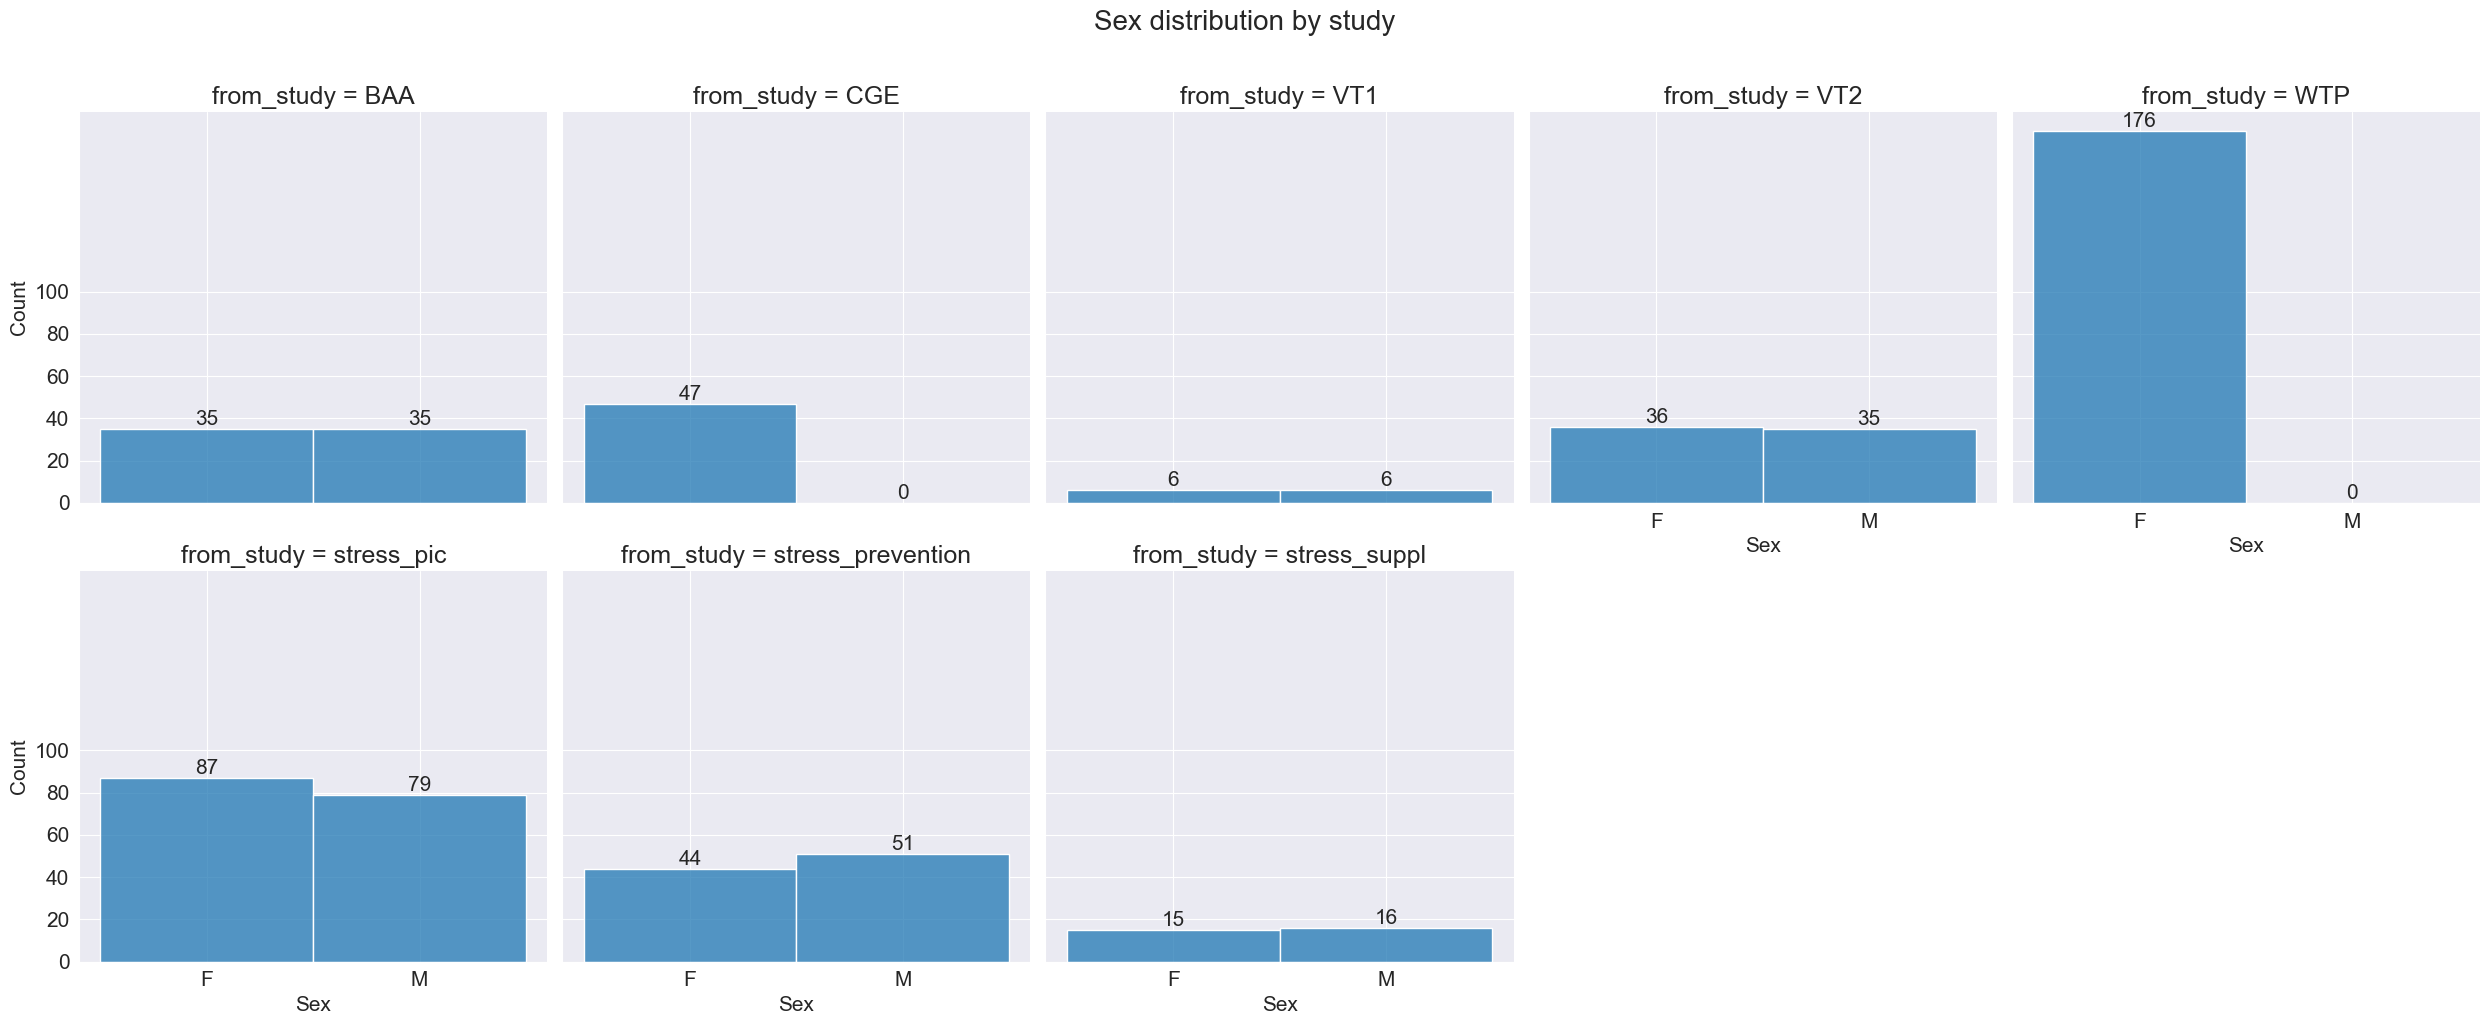

In [128]:
ax1 = sns.displot(
    data=physio_demo_df_B1,
    x='sex',
    col='from_study',
    col_wrap=5,
    # height=4,
    # aspect=1.2
)

for ax in ax1.axes.flat:
    ax.title.set_fontsize(18)
    ax.tick_params(axis='both', labelsize=15)
    if ax.containers:
        ax.bar_label(ax.containers[0], fontsize=15)
    ax.set_xlabel('Sex', fontsize=15)
    ax.set_ylabel('Count',fontsize=15)
    ax.set_yticks(np.arange(0,101,20))

plt.suptitle('Sex distribution by study', y=1.02, fontsize=20)

plt.tight_layout()
plt.show()

In [129]:
demo_df_sex_race = physio_demo_df_B1.groupby(['sex', 'race_text'], observed=True).size().reset_index(name='count')

demo_df_sex_race['percentage'] = ((demo_df_sex_race['count'] / demo_df_sex_race['count'].sum())*100).round(2)

demo_df_sex_race.sort_values(by=['race_text','percentage'], ascending=[False,True]).reset_index(drop=True, inplace=True)

demo_df_sex_race

,sex,race_text,count,percentage
0,F,American Indian or Alaska Native,2,0.31
1,F,Asian,44,6.79
2,F,Black or African American,39,6.02
3,F,Native Hawaiian or Other Pacific Islander,7,1.08
4,F,Other,22,3.40
5,F,White,325,50.15
6,M,American Indian or Alaska Native,1,0.15
7,M,Asian,39,6.02
8,M,Black or African American,12,1.85
9,M,Native Hawaiian or Other Pacific Islander,2,0.31


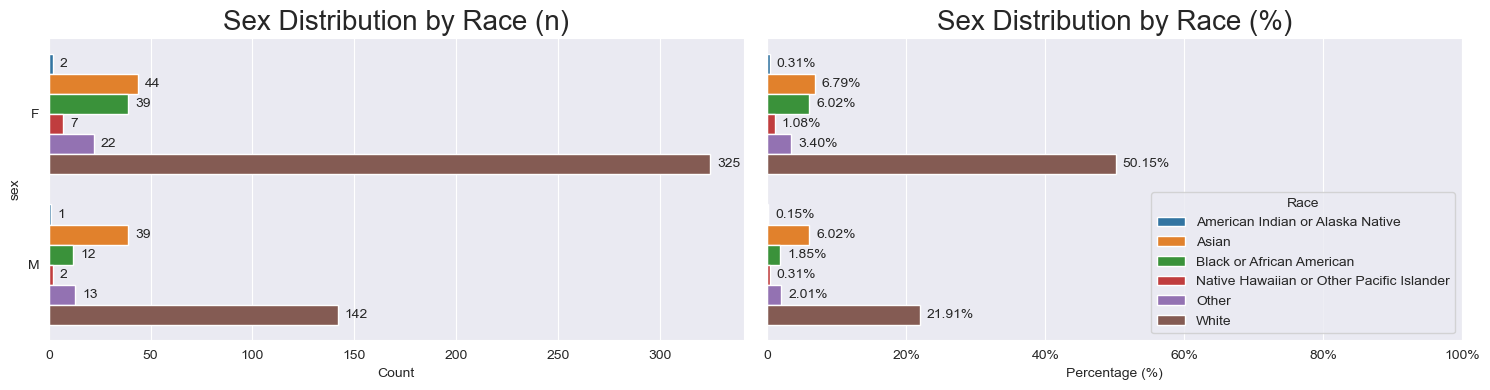

In [130]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,4))

ax1 = sns.barplot(data=demo_df_sex_race, x='count', y='sex',hue='race_text', errorbar=None, ax=ax[0])


ax1.set_xlabel('Count')
ax1.set_title('Sex Distribution by Race (n)', fontsize=20)

for container in ax1.containers:
    ax1.bar_label(container, fontsize=10, padding=5)


ax1.get_legend().remove()

ax2 = sns.barplot(data=demo_df_sex_race, x='percentage', y='sex', hue='race_text', errorbar=None, ax=ax[1])

ax2.set_xlabel('Percentage (%)')
ax2.set_title('Sex Distribution by Race (%)', fontsize=20)

for container in ax2.containers:
    ax2.bar_label(container, labels=[f'{v.get_width():.2f}%' for v in container], fontsize=10, padding= 5)

ax2.set_xticks(np.arange(0,101,20), labels=['0', '20%', '40%', '60%', '80%', '100%'])

ax2.get_legend().set_title('Race')

plt.tight_layout()
plt.show()

### Quick reference plot of all demographic variables side-by-side.

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_98948/4065070038.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_98948/4065070038.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)


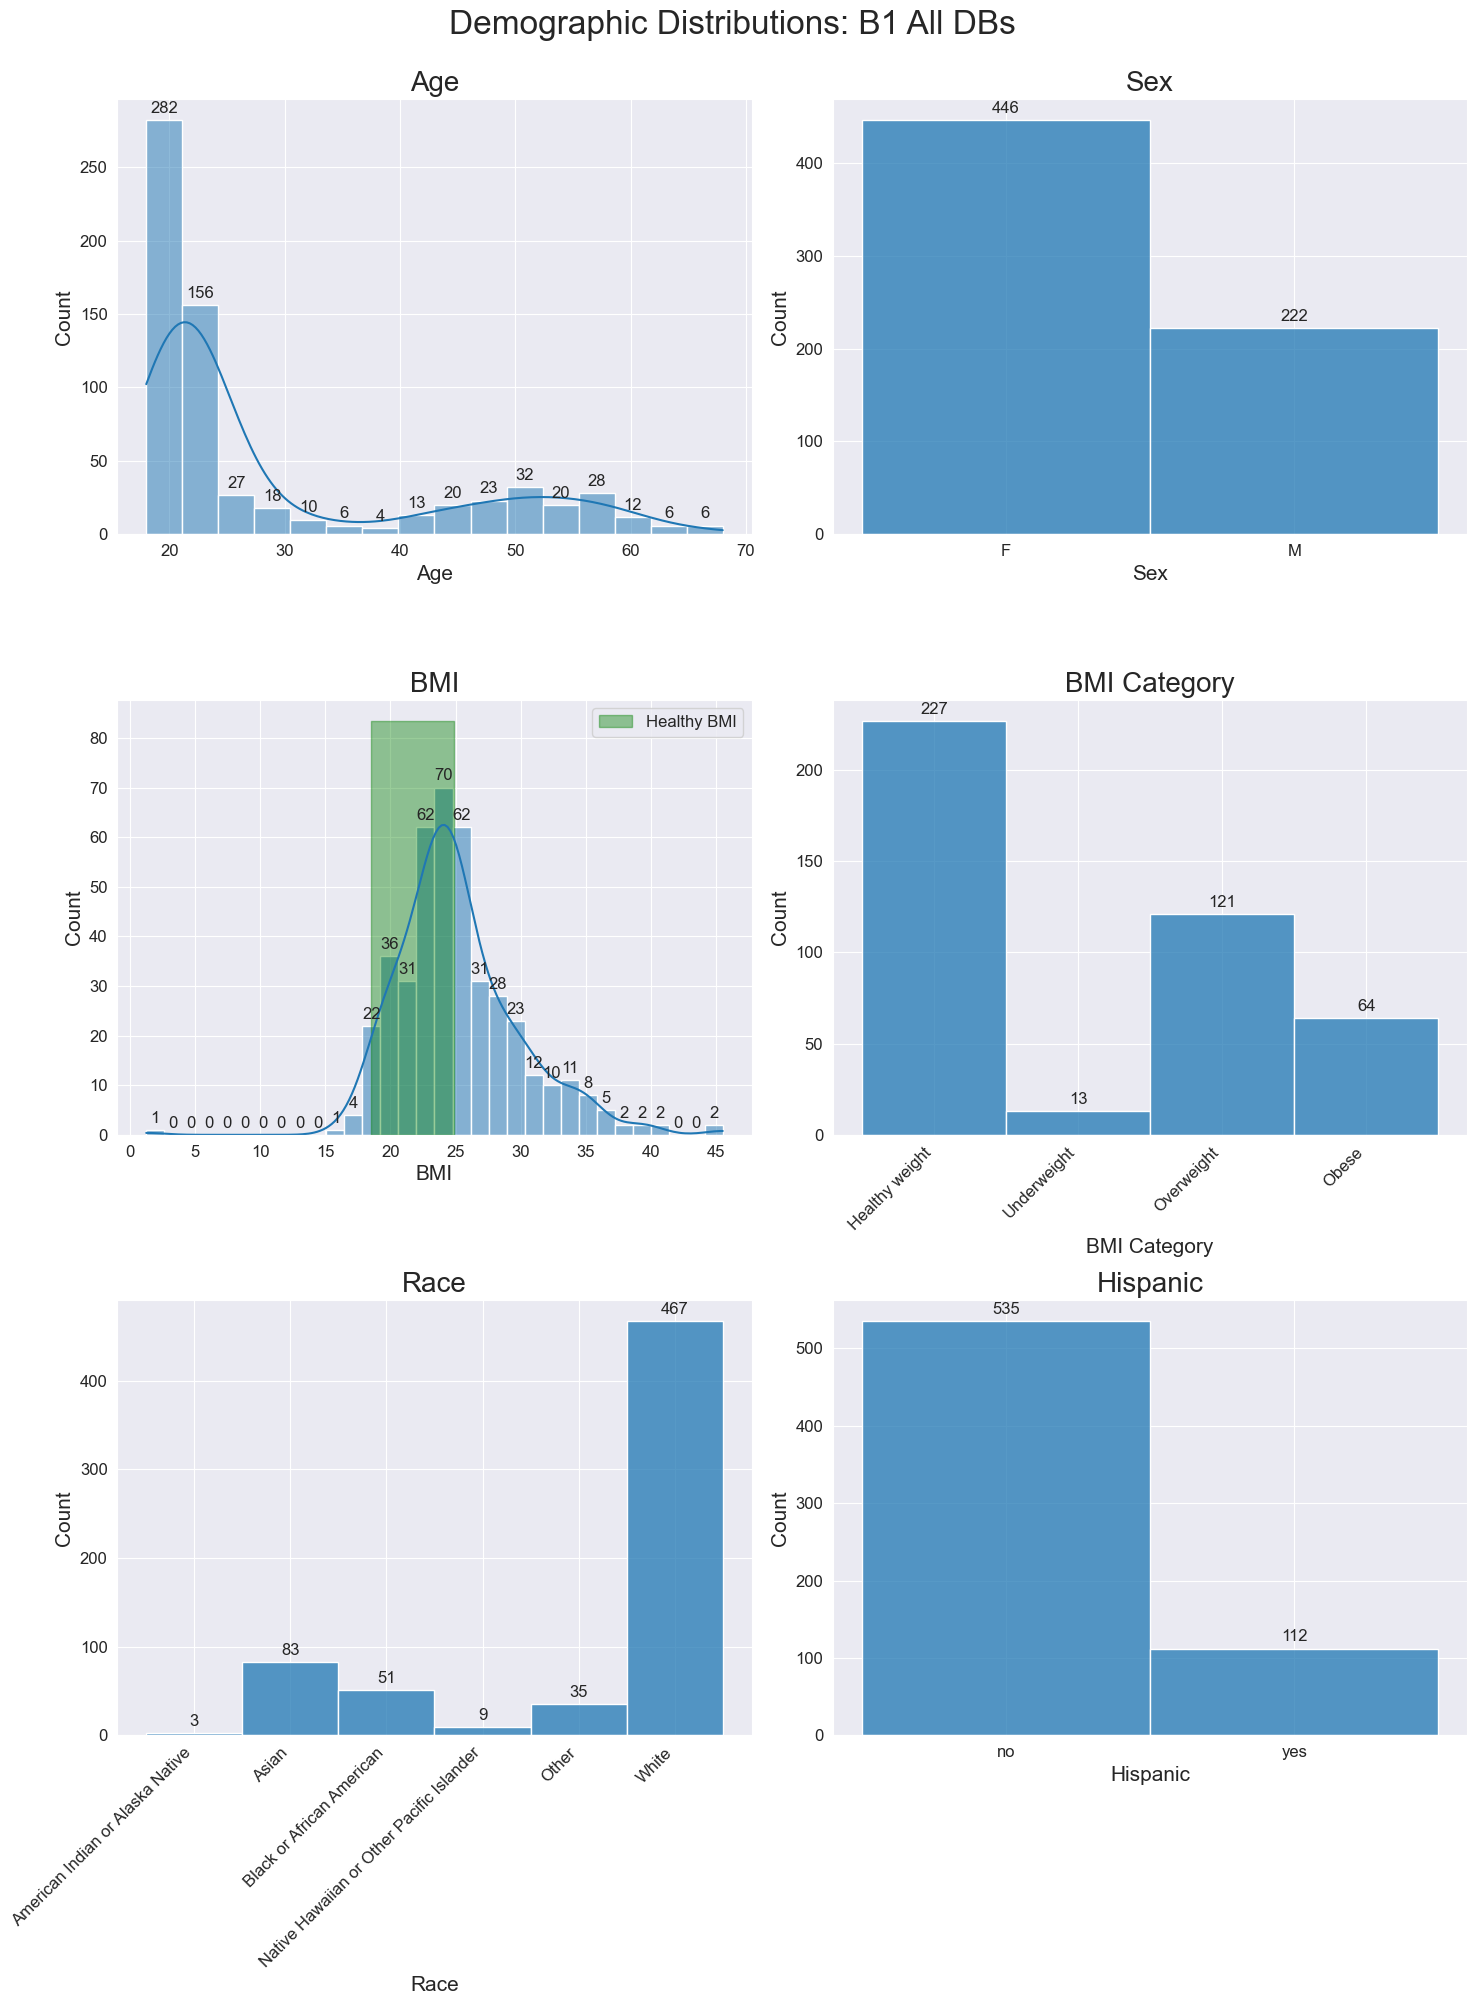

In [131]:
fig, ax = plt.subplots(3,2, figsize=(15,20))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age',kde=True, ax=ax[0,0])
ax1.bar_label(ax1.containers[0], fontsize=12, padding=3)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title('Age', fontsize=20)
ax1.set_ylabel('Count', fontsize=15)
ax1.set_xlabel('Age', fontsize=15)

ax2 = sns.histplot(data=physio_demo_df_B1, x='sex', ax=ax[0,1])
ax2.bar_label(ax2.containers[0], fontsize=12, padding=3)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title('Sex', fontsize=20)
ax2.set_ylabel('Count', fontsize=15)
ax2.set_xlabel('Sex', fontsize=15)

ax3 = sns.histplot(data=physio_demo_df_B1, x='bmi', kde=True, ax=ax[1,0])
ax3.bar_label(ax3.containers[0], fontsize=12, padding=3)
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_xticks(np.arange(0,51,5))
ax3.set_title('BMI', fontsize=20)
ax3.set_ylabel('Count', fontsize=15)
ax3.set_xlabel('BMI', fontsize=15)
ax3.fill_between(x=[18.5, 24.9], y1=0, y2=ax3.get_ylim()[1]+10, color='green', alpha=0.4, label='Healthy BMI')
ax3.legend(fontsize=12)

ax4 = sns.histplot(data=physio_demo_df_B1, x='bmi_cat', ax=ax[1,1])
ax4.bar_label(ax4.containers[0], fontsize=12, padding=3)
ax4.tick_params(axis='both', which='major', labelsize=12)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax4.set_title('BMI Category', fontsize=20)
ax4.set_ylabel('Count', fontsize=15)
ax4.set_xlabel('BMI Category', fontsize=15)

# ax5 = sns.histplot(data=physio_demo_df_B1, x='bmi_cat_simple'

ax6 = sns.histplot(data=physio_demo_df_B1, x='race_text', ax=ax[2,0])
ax6.bar_label(ax6.containers[0], fontsize=12, padding=3)
ax6.tick_params(axis='both', which='major', labelsize=12)
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax6.set_title('Race', fontsize=20)
ax6.set_ylabel('Count', fontsize=15)
ax6.set_xlabel('Race', fontsize=15)

ax7 = sns.histplot(data=physio_demo_df_B1, x='hispanic', ax=ax[2,1])
ax7.bar_label(ax7.containers[0], fontsize=12, padding=3)
ax7.tick_params(axis='both', which='major', labelsize=12)
ax7.set_title('Hispanic', fontsize=20)
ax7.set_ylabel('Count', fontsize=15)
ax7.set_xlabel('Hispanic', fontsize=15)

plt.suptitle('Demographic Distributions: B1 All DBs', fontsize=24, y=1.0)
plt.tight_layout()
plt.show()

## Transforming the HRV metrics

- Using natural log (until I hear if a different log should be used)
- Adding (concat) these to the df before splitting up by study
  

In [132]:
# list(physio_demo_df.columns)
HRV_metrics = ['RRIMin',
 'RRImax',
 'RRImean',
 'RRIRmssd',
 'RRIPnn50',
'RRISTot',
 'RRISUlf',
 'RRISVlf',
 'RRISLf',
 'RRISHf',
 'RRISLfHF',
 'RRISnLf',
 'RRISnHf',
 'RRI',
]

resp_measures = ['RVFMean', 'RVFDev']

## Frequency domain HRV measures that need to be log transformed for normality in future analyses
HRV_to_transform = [
 'RRISTot',
 'RRISUlf',
 'RRISVlf',
 'RRISLf',
 'RRISHf',
 'RRISLfHF',
 'RRISnLf',
 'RRISnHf',
 'RRI',
 'RRIRmssd',
 'RRIPnn50',
]

## Time domain HRV measures that can be used in their original form without transformation
HR_metrics_vanilla = [
'HRMean',
'HRDev',
'RRIMin',
 'RRImax',
 'RRImean',
 'RRIRmssd',
 'RRIPnn50'
]

In [133]:
ln_columns = {}

for metric in HRV_to_transform:
    ln_columns[f'{metric}_ln'] = physio_demo_df[metric].apply(lambda x: math.log(x) if pd.notnull(x) and x > 0 else np.nan).round(2)

physio_demo_df = pd.concat([physio_demo_df, pd.DataFrame(ln_columns)], axis=1)

physio_demo_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,152000,VT1,B1,689,1066,838,39,19.7,53,4.7,...,5.22,5.87,6.35,6.09,4.86,-0.84,NaN,7.29,3.66,2.98
1,152000,VT1,6P,662,1207,882,93,40.5,133,10.5,...,3.18,5.65,9.52,7.88,6.24,-1.82,NaN,14.16,4.53,3.70
2,152002,VT1,B1,673,992,850,33,10.6,57,3.9,...,5.53,6.48,6.56,5.44,5.73,-1.41,NaN,10.69,3.50,2.36
3,152002,VT1,6P,617,1118,878,87,45.5,148,9.9,...,4.61,6.68,9.78,7.49,6.89,-2.39,NaN,14.40,4.47,3.82
4,152004,VT1,B1,702,961,814,24,1.4,38,2.9,...,2.20,5.45,5.91,5.27,5.25,-1.08,NaN,8.36,3.18,0.34


In [134]:
transformed_HRV_cols = list(ln_columns)

transformed_HRV_cols

['RRISTot_ln',
 'RRISUlf_ln',
 'RRISVlf_ln',
 'RRISLf_ln',
 'RRISHf_ln',
 'RRISLfHF_ln',
 'RRISnLf_ln',
 'RRISnHf_ln',
 'RRI_ln',
 'RRIRmssd_ln',
 'RRIPnn50_ln']

In [135]:
### all phyisological variables for potential analysis (both transformed and untransformed)
all_physio_vars = HRV_metrics + transformed_HRV_cols + resp_measures

### main phyisological variables to analyze
main_physio_vars = HR_metrics_vanilla + transformed_HRV_cols + resp_measures

main_physio_vars.sort()
## sorts the variables alphabetically to allow subplots of variables + transformed variables to be assessed side-by-side

In [136]:
physio_corr_matrix = physio_demo_df[main_physio_vars].corr().round(2)

physio_corr_matrix.tail()

,HRDev,HRMean,RRIMin,RRIPnn50,RRIPnn50_ln,RRIRmssd,RRIRmssd_ln,RRISHf_ln,RRISLfHF_ln,RRISLf_ln,RRISTot_ln,RRISUlf_ln,RRISVlf_ln,RRISnHf_ln,RRISnLf_ln,RRI_ln,RRImax,RRImean,RVFDev,RVFMean
RRI_ln,0.68,-0.19,-0.09,0.36,0.41,0.41,0.53,0.47,0.63,0.91,0.80,0.30,0.36,-0.64,0.17,1.00,0.43,0.21,-0.11,-0.70
RRImax,0.32,-0.71,0.34,0.68,0.54,0.81,0.79,0.65,-0.04,0.54,0.63,0.40,0.55,0.04,-0.04,0.43,1.00,0.75,0.01,-0.00
RRImean,-0.11,-0.97,0.74,0.60,0.44,0.54,0.54,0.44,-0.22,0.20,0.31,0.26,0.35,0.21,-0.20,0.21,0.75,1.00,-0.00,0.04
RVFDev,0.03,-0.00,-0.01,0.01,0.01,0.01,0.02,-0.01,0.03,0.01,0.01,0.01,0.03,-0.03,0.01,-0.11,0.01,-0.00,1.00,0.48
RVFMean,-0.06,-0.04,0.06,0.03,0.02,-0.01,0.00,-0.10,-0.07,-0.15,-0.14,-0.07,-0.08,0.18,-0.09,-0.70,-0.00,0.04,0.48,1.00


### Heatmap Correlation Matrix of HRV_ln and Respiratory measures (sample)

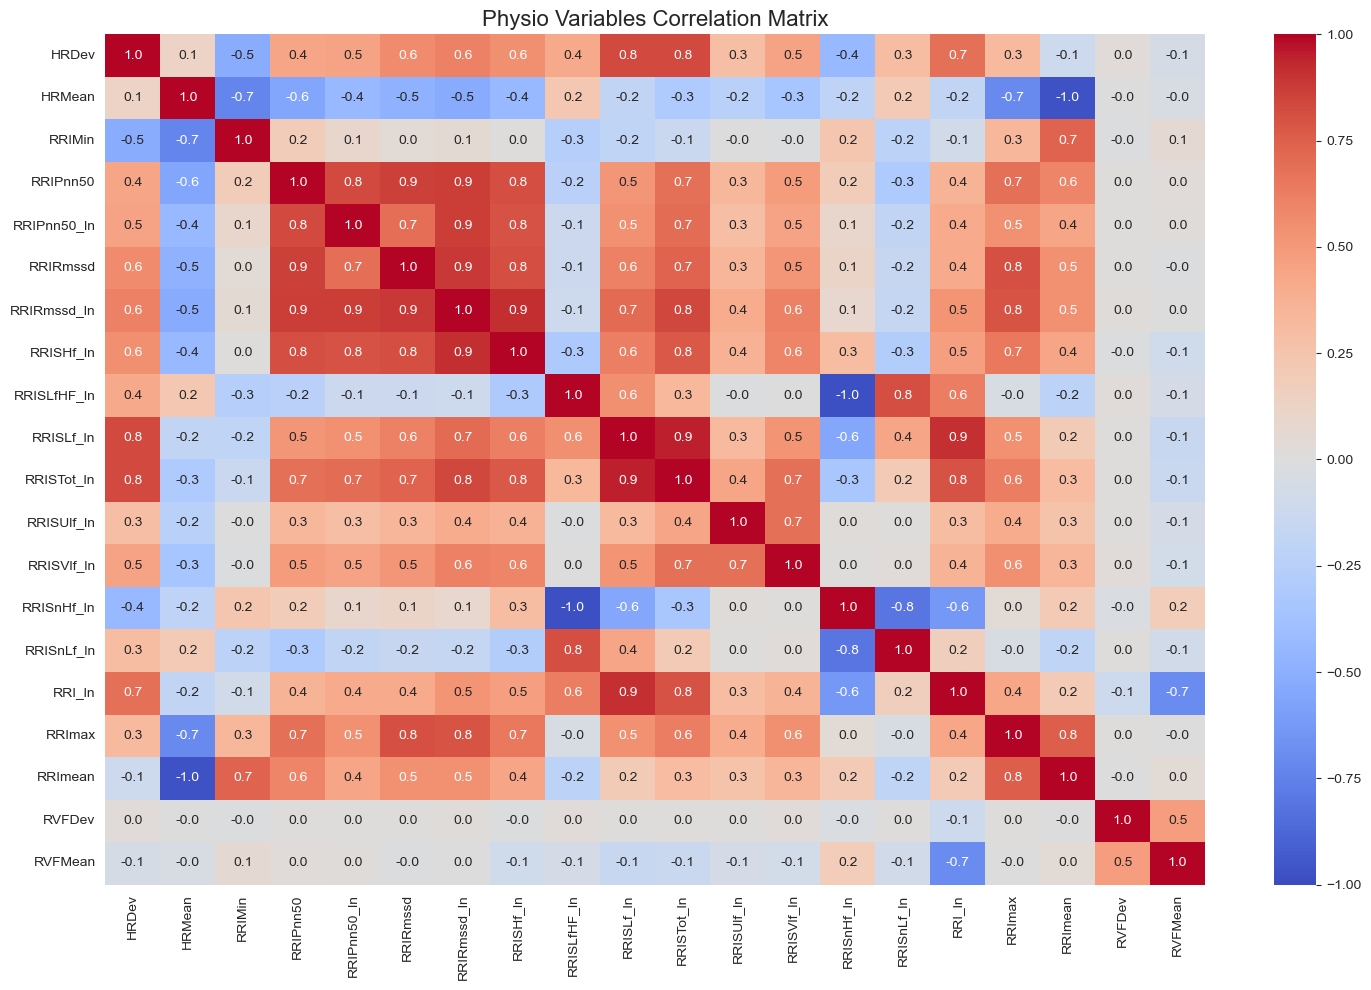

In [137]:
## Full heat matrix of correlations
fig, ax = plt.subplots(figsize=(15,10))
mask = np.triu(np.ones_like(physio_corr_matrix, dtype=bool))
sns.heatmap(
    physio_corr_matrix,
    # mask=mask,  ## toggle on/off the mask to show full matrix or just lower triangle
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1
)

ax.set_title('Physio Variables Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

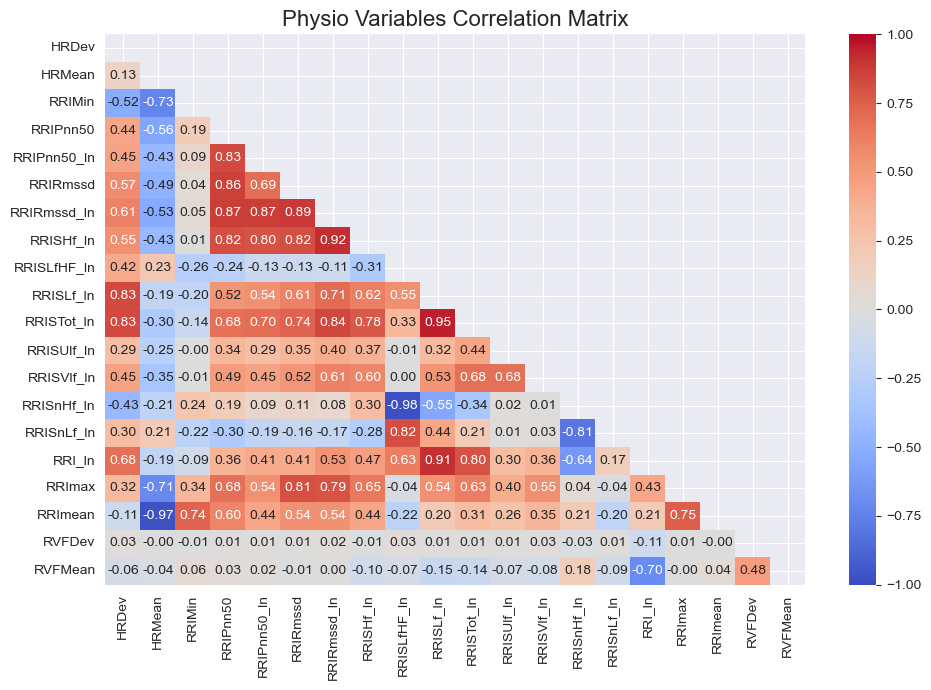

In [138]:
## Triangle correlation matrix (remove upper half)
## Create mask for upper triangle
# fig, ax = plt.subplots(figsize=(20,16))
fig, ax = plt.subplots(figsize=(10,7))
mask = np.triu(np.ones_like(physio_corr_matrix, dtype=bool))

sns.heatmap(
    physio_corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1
)

ax.set_title('Physio Variables Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### Modifiable correlation heat matrix column

- This lets you look at correlations against just one variable (target_variable) vs. the entire heat map correlation matrix
- correlation are sorted highest to lowest r value. 

In [139]:
list(main_physio_vars)

['HRDev',
 'HRMean',
 'RRIMin',
 'RRIPnn50',
 'RRIPnn50_ln',
 'RRIRmssd',
 'RRIRmssd_ln',
 'RRISHf_ln',
 'RRISLfHF_ln',
 'RRISLf_ln',
 'RRISTot_ln',
 'RRISUlf_ln',
 'RRISVlf_ln',
 'RRISnHf_ln',
 'RRISnLf_ln',
 'RRI_ln',
 'RRImax',
 'RRImean',
 'RVFDev',
 'RVFMean']

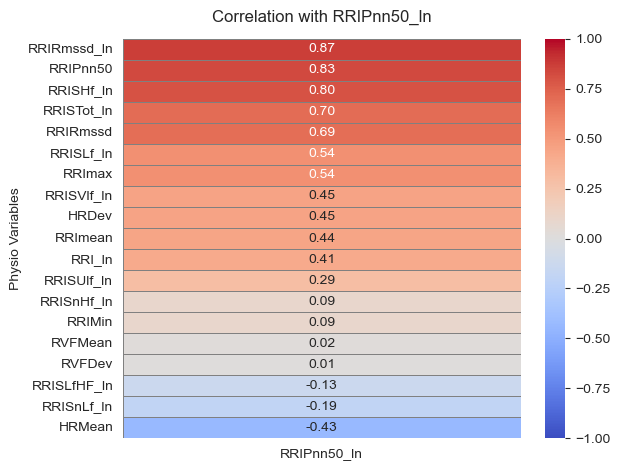

In [140]:
## Single-column heatmap: all physio variables
## change target variable as desired
target_variable = 'RRIPnn50_ln'

## Compute correlations of all variables vs HRmean, drop the self-correlation
corr_values = physio_corr_matrix[[target_variable]].drop(index=target_variable).sort_values(by=target_variable, ascending=False)

fig, ax = plt.subplots()

sns.heatmap(
    corr_values,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title(f'Correlation with {target_variable}', fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Physio Variables', fontsize=10)
plt.tight_layout()
plt.show()

### Check Distribution of main physiological variables.

In [141]:
physio_demo_df[main_physio_vars].astype(dtype=float, errors='ignore')

,HRDev,HRMean,RRIMin,RRIPnn50,RRIPnn50_ln,RRIRmssd,RRIRmssd_ln,RRISHf_ln,RRISLfHF_ln,RRISLf_ln,RRISTot_ln,RRISUlf_ln,RRISVlf_ln,RRISnHf_ln,RRISnLf_ln,RRI_ln,RRImax,RRImean,RVFDev,RVFMean
0,4.6,71.9,689.0,19.7,2.98,39.0,3.66,6.09,4.86,6.35,7.35,5.22,5.87,NaN,-0.84,7.29,1066.0,838.0,0.09,0.32
1,10.4,69.6,662.0,40.5,3.70,93.0,4.53,7.88,6.24,9.52,9.72,3.18,5.65,NaN,-1.82,14.16,1207.0,882.0,0.00,0.09
2,5.0,71.0,673.0,10.6,2.36,33.0,3.50,5.44,5.73,6.56,7.53,5.53,6.48,NaN,-1.41,10.69,992.0,850.0,0.03,0.32
3,12.5,70.4,617.0,45.5,3.82,87.0,4.47,7.49,6.89,9.78,9.92,4.61,6.68,NaN,-2.39,14.40,1118.0,878.0,0.12,0.18
4,3.4,73.8,702.0,1.4,0.34,24.0,3.18,5.27,5.25,5.91,6.70,2.20,5.45,NaN,-1.08,8.36,961.0,814.0,0.02,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1343,6.5,76.3,667.0,20.1,3.00,40.0,3.69,5.62,7.17,8.19,8.40,4.55,6.12,-2.65,-0.08,NaN,936.0,793.0,0.01,0.10
1344,2.3,109.2,518.0,0.0,NaN,4.0,1.39,1.61,6.91,4.01,5.09,3.56,4.20,-2.41,-0.10,NaN,582.0,550.0,0.03,0.32
1345,3.2,105.8,535.0,0.0,NaN,6.0,1.79,2.64,7.06,5.12,5.47,3.00,3.61,-2.54,-0.08,NaN,635.0,568.0,0.00,0.10
1346,4.3,69.3,715.0,32.3,3.48,51.0,3.93,5.87,5.98,7.25,7.83,4.99,6.24,-1.66,-0.28,NaN,1039.0,869.0,0.05,0.40


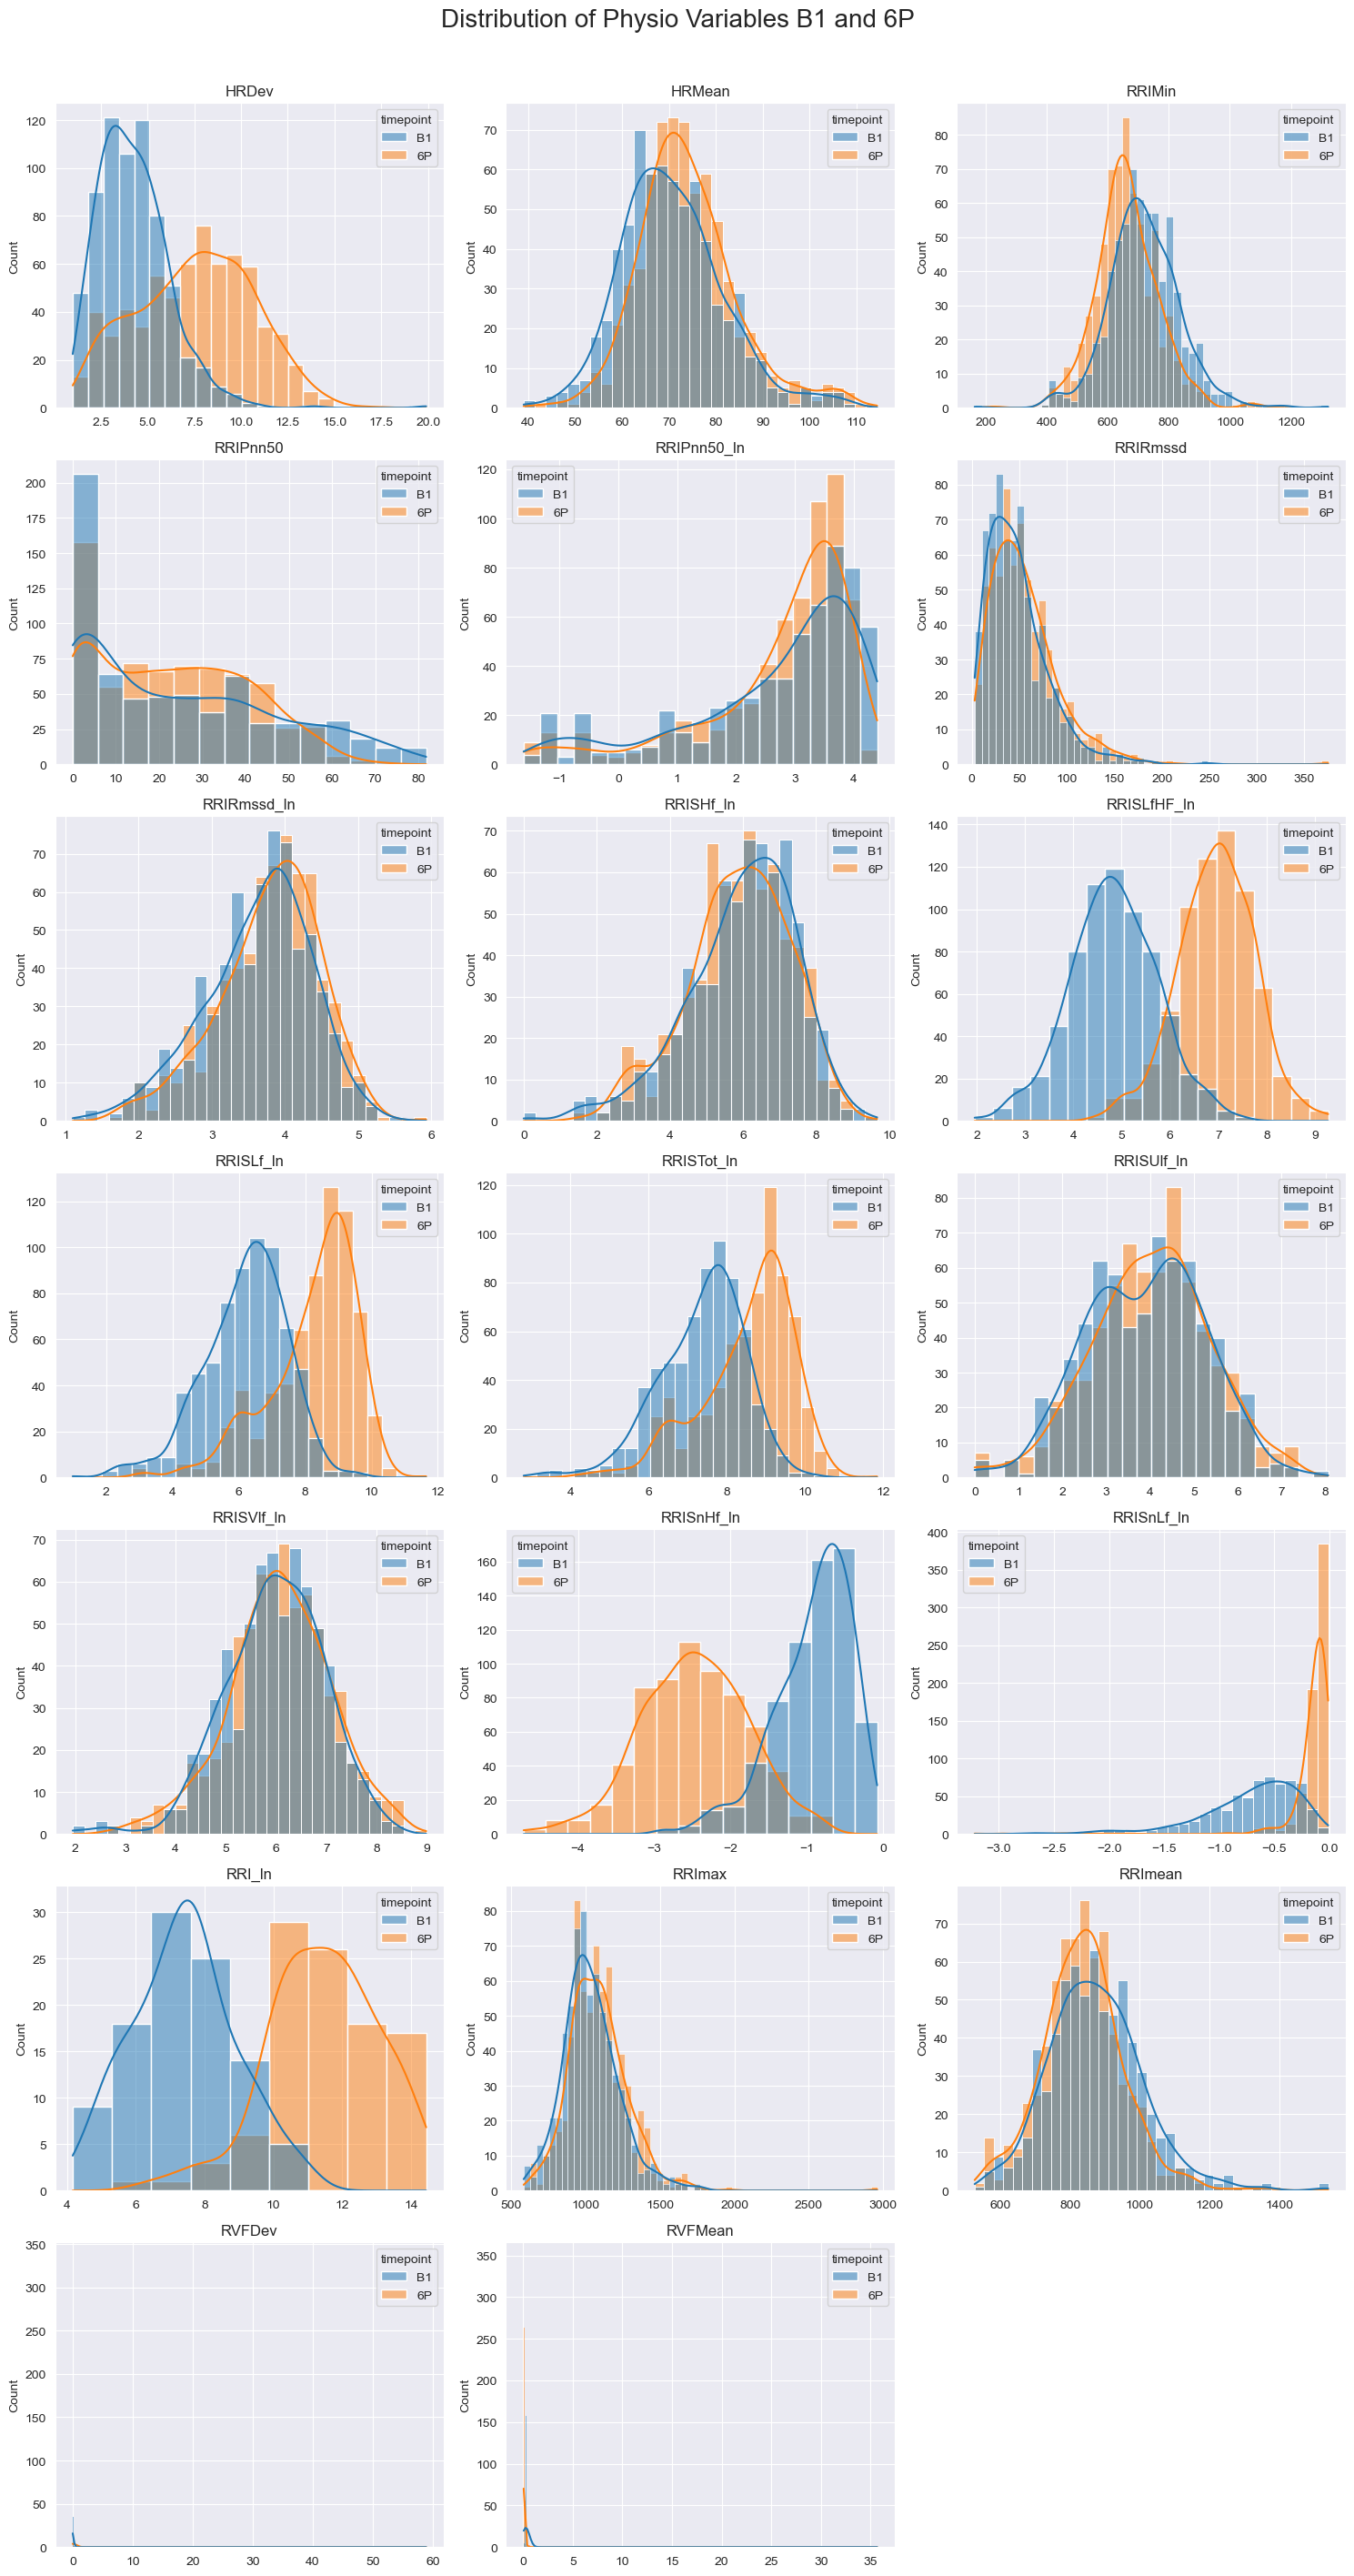

In [142]:
# physio_df_b1

ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.histplot(data=physio_demo_df, x=var, hue= 'timepoint', hue_order=['B1', '6P'], multiple= 'layer', kde=True, ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    # axes[i].axvline(physio_demo_df[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    # axes[i].axvline(float(physio_demo_df[var].median()), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables B1 and 6P', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

## Statistics

### Descriptive Statistics

In [143]:
## A look at descriptive statistics for the main physiological variables, by timepoint
## Can be used for quick reference and to use for manually constructing plots with this descriptive df as the source (e.g., error bars, boxplot whiskers, etc.)

descriptives_df = (physio_demo_df
.groupby('timepoint', observed=False)[main_physio_vars]
 .describe()
 .round(2)
.stack(level=0)
.rename_axis(['timepoint', 'variable'])
.reset_index()
.reindex(columns=['variable', 'timepoint'] + ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'])
)

descriptives_df.sort_values(by=['timepoint', 'variable'], ascending=[False, True], inplace=True)

descriptives_df.head(10)

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_98948/4243809309.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=0)


,variable,timepoint,count,mean,std,min,25%,50%,75%,max
20,HRDev,B1,674.0,4.25,1.92,1.20,2.90,4.00,5.30,19.90
21,HRMean,B1,674.0,70.62,10.93,39.00,63.20,69.55,76.70,109.20
22,RRIMin,B1,674.0,718.15,116.27,164.00,647.25,711.50,792.00,1322.00
23,RRIPnn50,B1,674.0,24.62,22.45,0.00,2.80,20.00,40.02,81.80
24,RRIPnn50_ln,B1,605.0,2.66,1.51,-1.61,1.93,3.18,3.74,4.40
25,RRIRmssd,B1,674.0,47.77,32.24,3.00,24.00,42.00,62.00,248.00
26,RRIRmssd_ln,B1,674.0,3.63,0.73,1.10,3.18,3.74,4.13,5.51
27,RRISHf_ln,B1,674.0,5.97,1.49,0.00,5.16,6.15,7.05,9.55
28,RRISLfHF_ln,B1,674.0,4.83,0.90,1.96,4.25,4.80,5.46,7.45
29,RRISLf_ln,B1,674.0,6.19,1.25,0.99,5.44,6.33,7.05,9.69


### Data normality assessment

In [144]:
pip install pingouin

Note: you may need to restart the kernel to use updated packages.


In [145]:
import pingouin as pg

In [146]:
physio_df_b1 = physio_demo_df[physio_demo_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

physio_df_b1.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,152000,VT1,B1,689,1066,838,39,19.7,53,4.7,...,5.22,5.87,6.35,6.09,4.86,-0.84,NaN,7.29,3.66,2.98
1,152002,VT1,B1,673,992,850,33,10.6,57,3.9,...,5.53,6.48,6.56,5.44,5.73,-1.41,NaN,10.69,3.50,2.36
2,152004,VT1,B1,702,961,814,24,1.4,38,2.9,...,2.20,5.45,5.91,5.27,5.25,-1.08,NaN,8.36,3.18,0.34
3,152006,VT1,B1,620,829,707,20,2.1,35,2.9,...,4.11,5.95,6.39,5.50,5.50,-1.25,NaN,10.59,3.00,0.74
4,152008,VT1,B1,725,1052,918,29,8.0,51,3.2,...,4.94,6.94,7.51,5.55,6.57,-2.10,NaN,10.54,3.37,2.08


**Note:** There are multiple, different iterations of the 'main' physiology variables plotted below:

- Timepoint (B1 or 6P) is specified by color, when applicable.

1) histograms of each physiology variable where the red dashed line = median (good for visual inspection of skewness)
2) Boxplot of each physiology variable (my personal favorite for examining data distribution between categorical variables).
3) Stripplot of each physiology variable, shows individual datapoints (has overlap) for general density of distribution
4) Violin plot of each physiogy variable, shows density distribution (similar to Boxplot + stripplot combined).

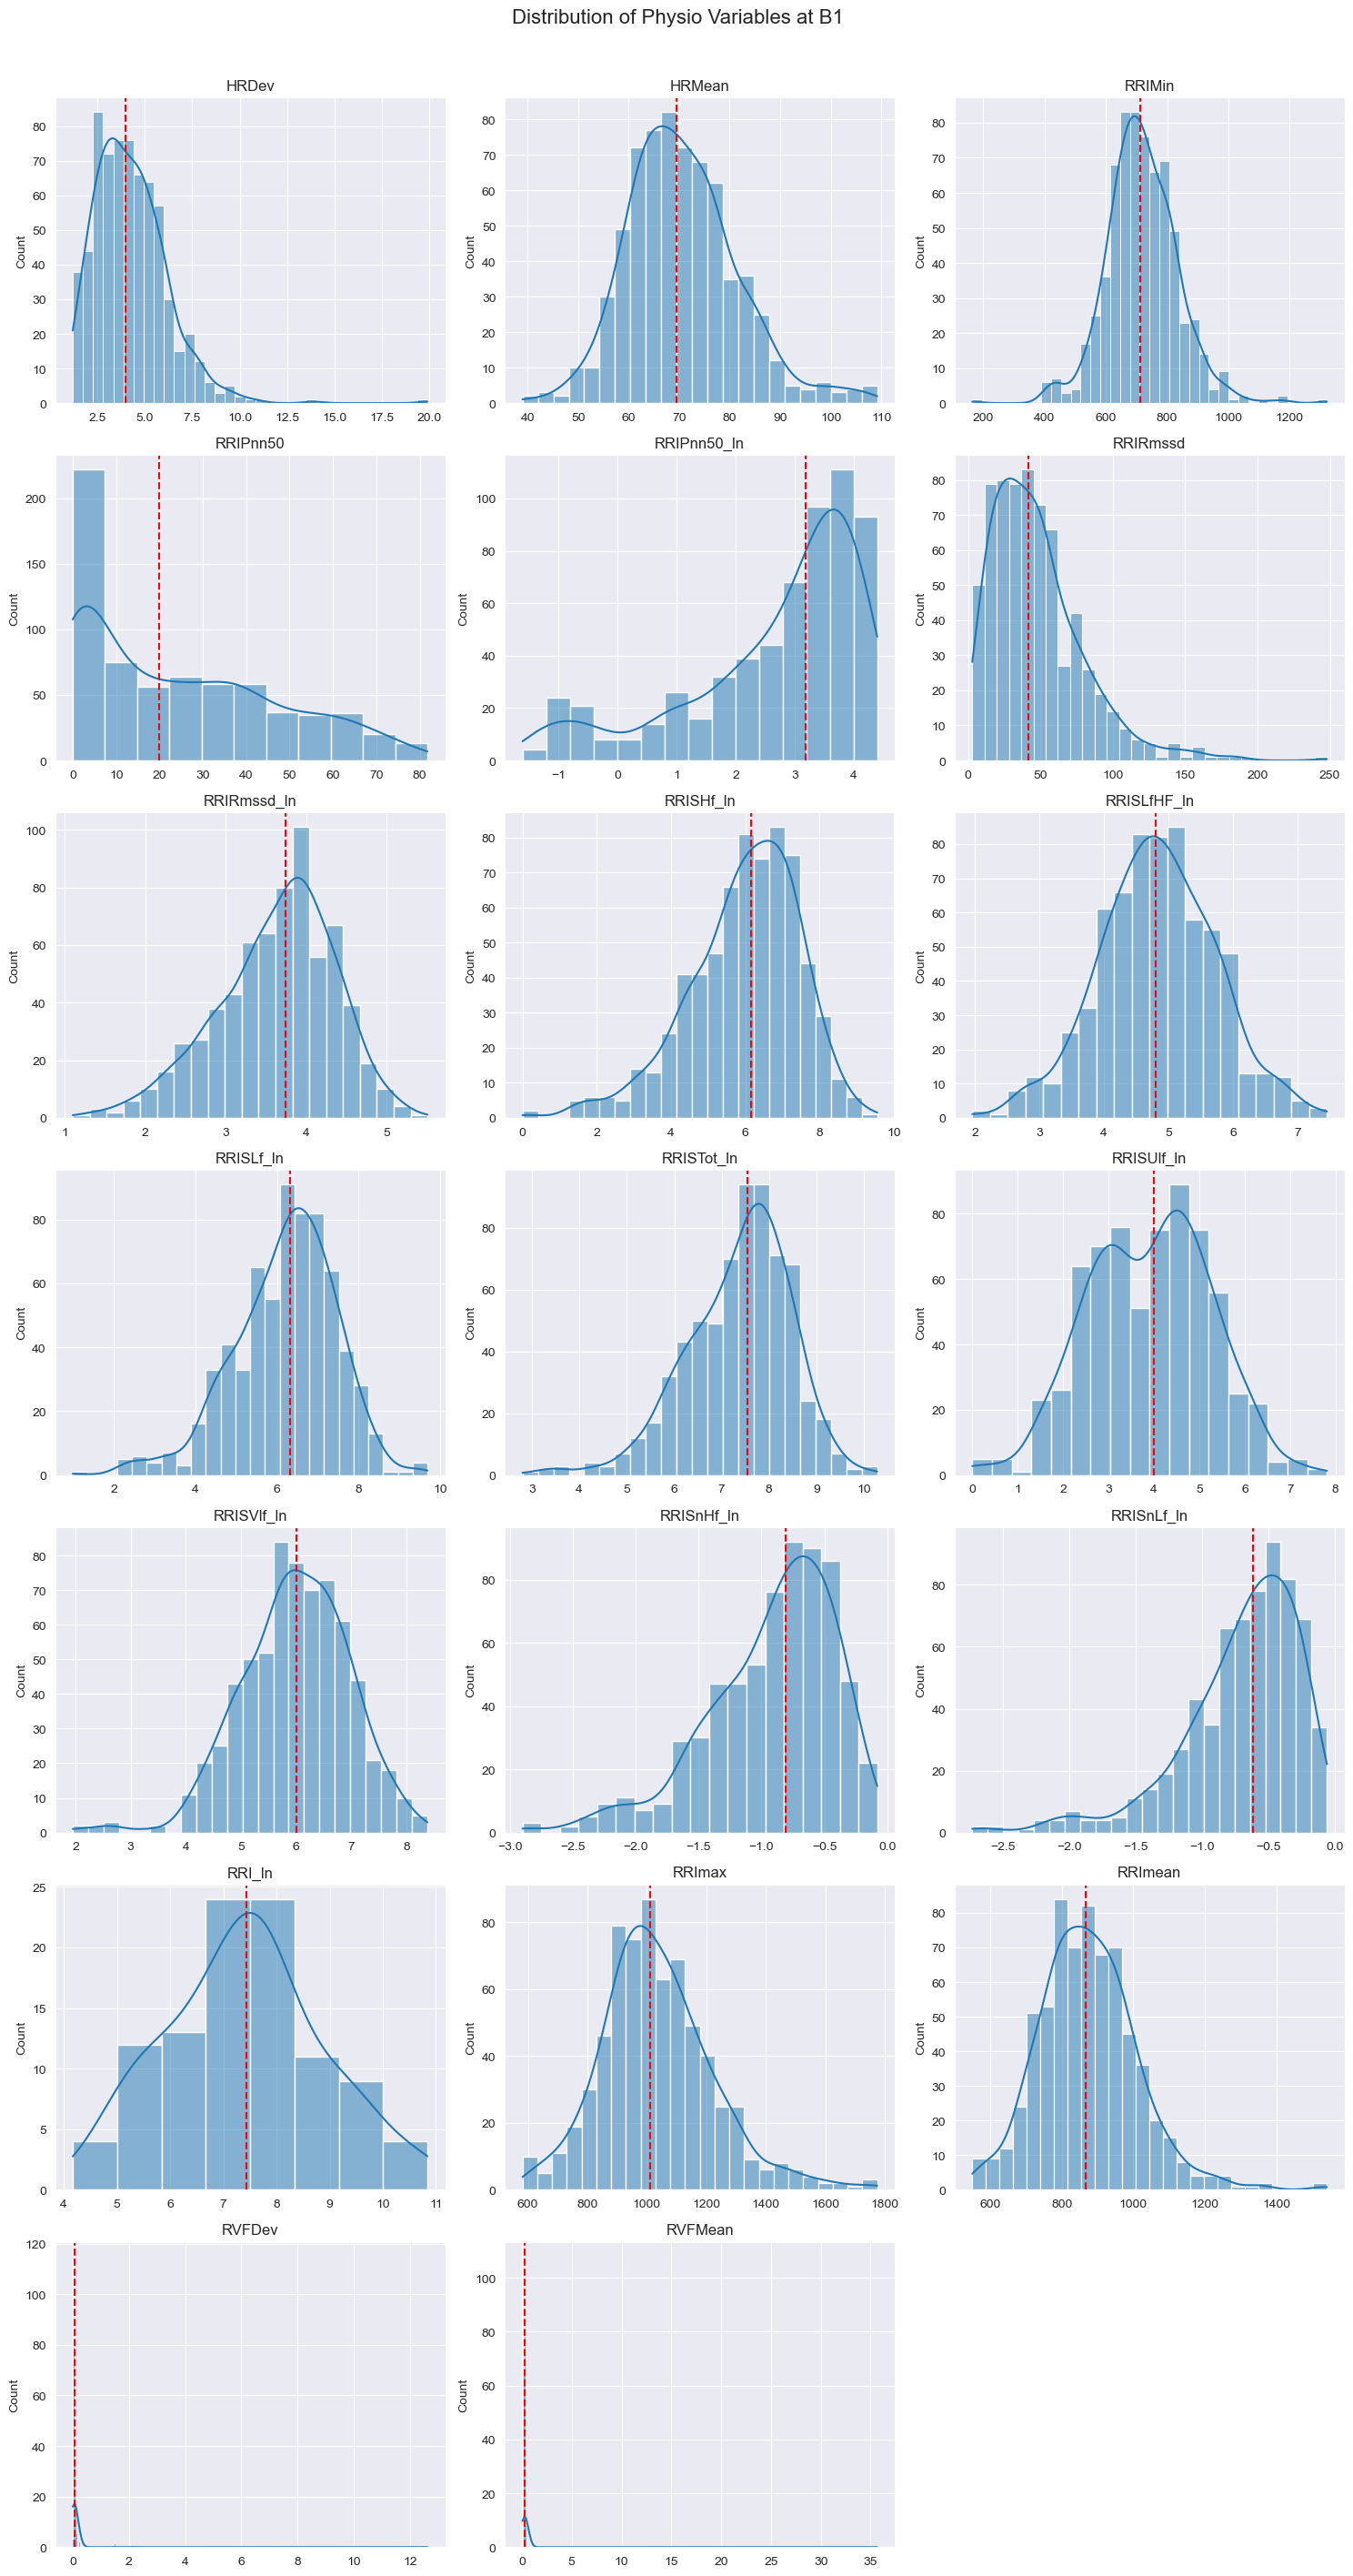

In [147]:
physio_df_b1

ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.histplot(data=physio_df_b1, x=var, kde=True, ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

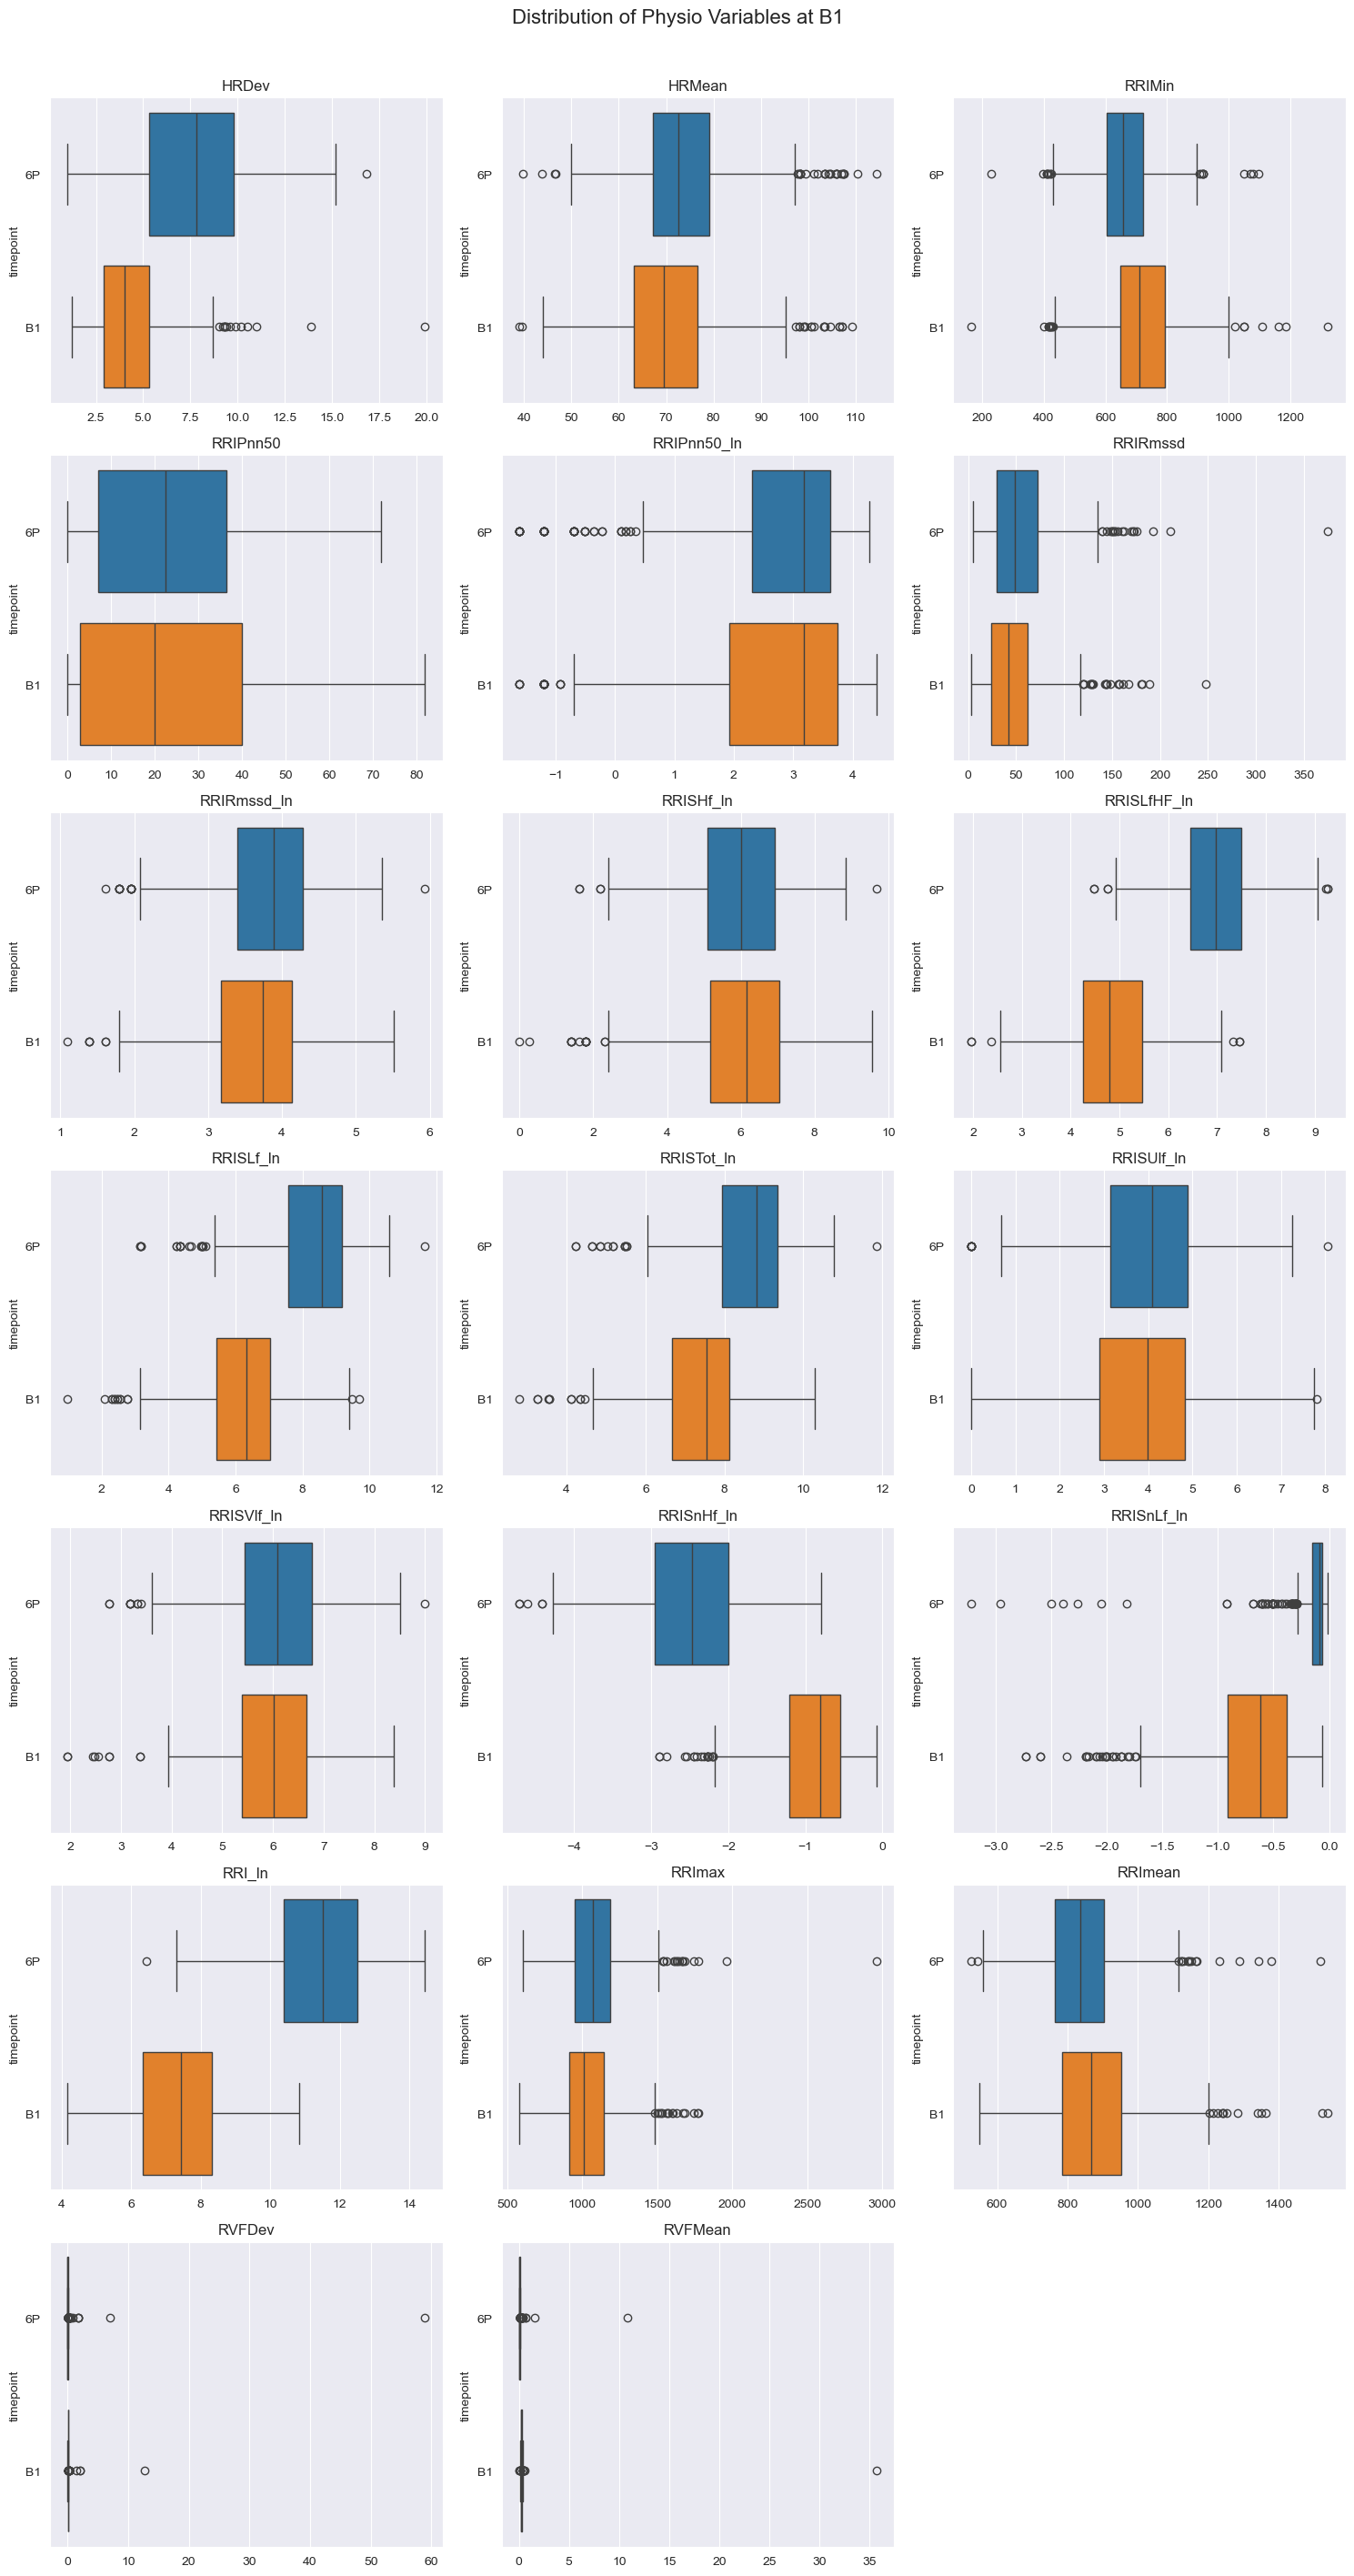

In [148]:
physio_df_b1

ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.boxplot(data=physio_demo_df, y='timepoint', x=var, hue='timepoint', ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    # axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

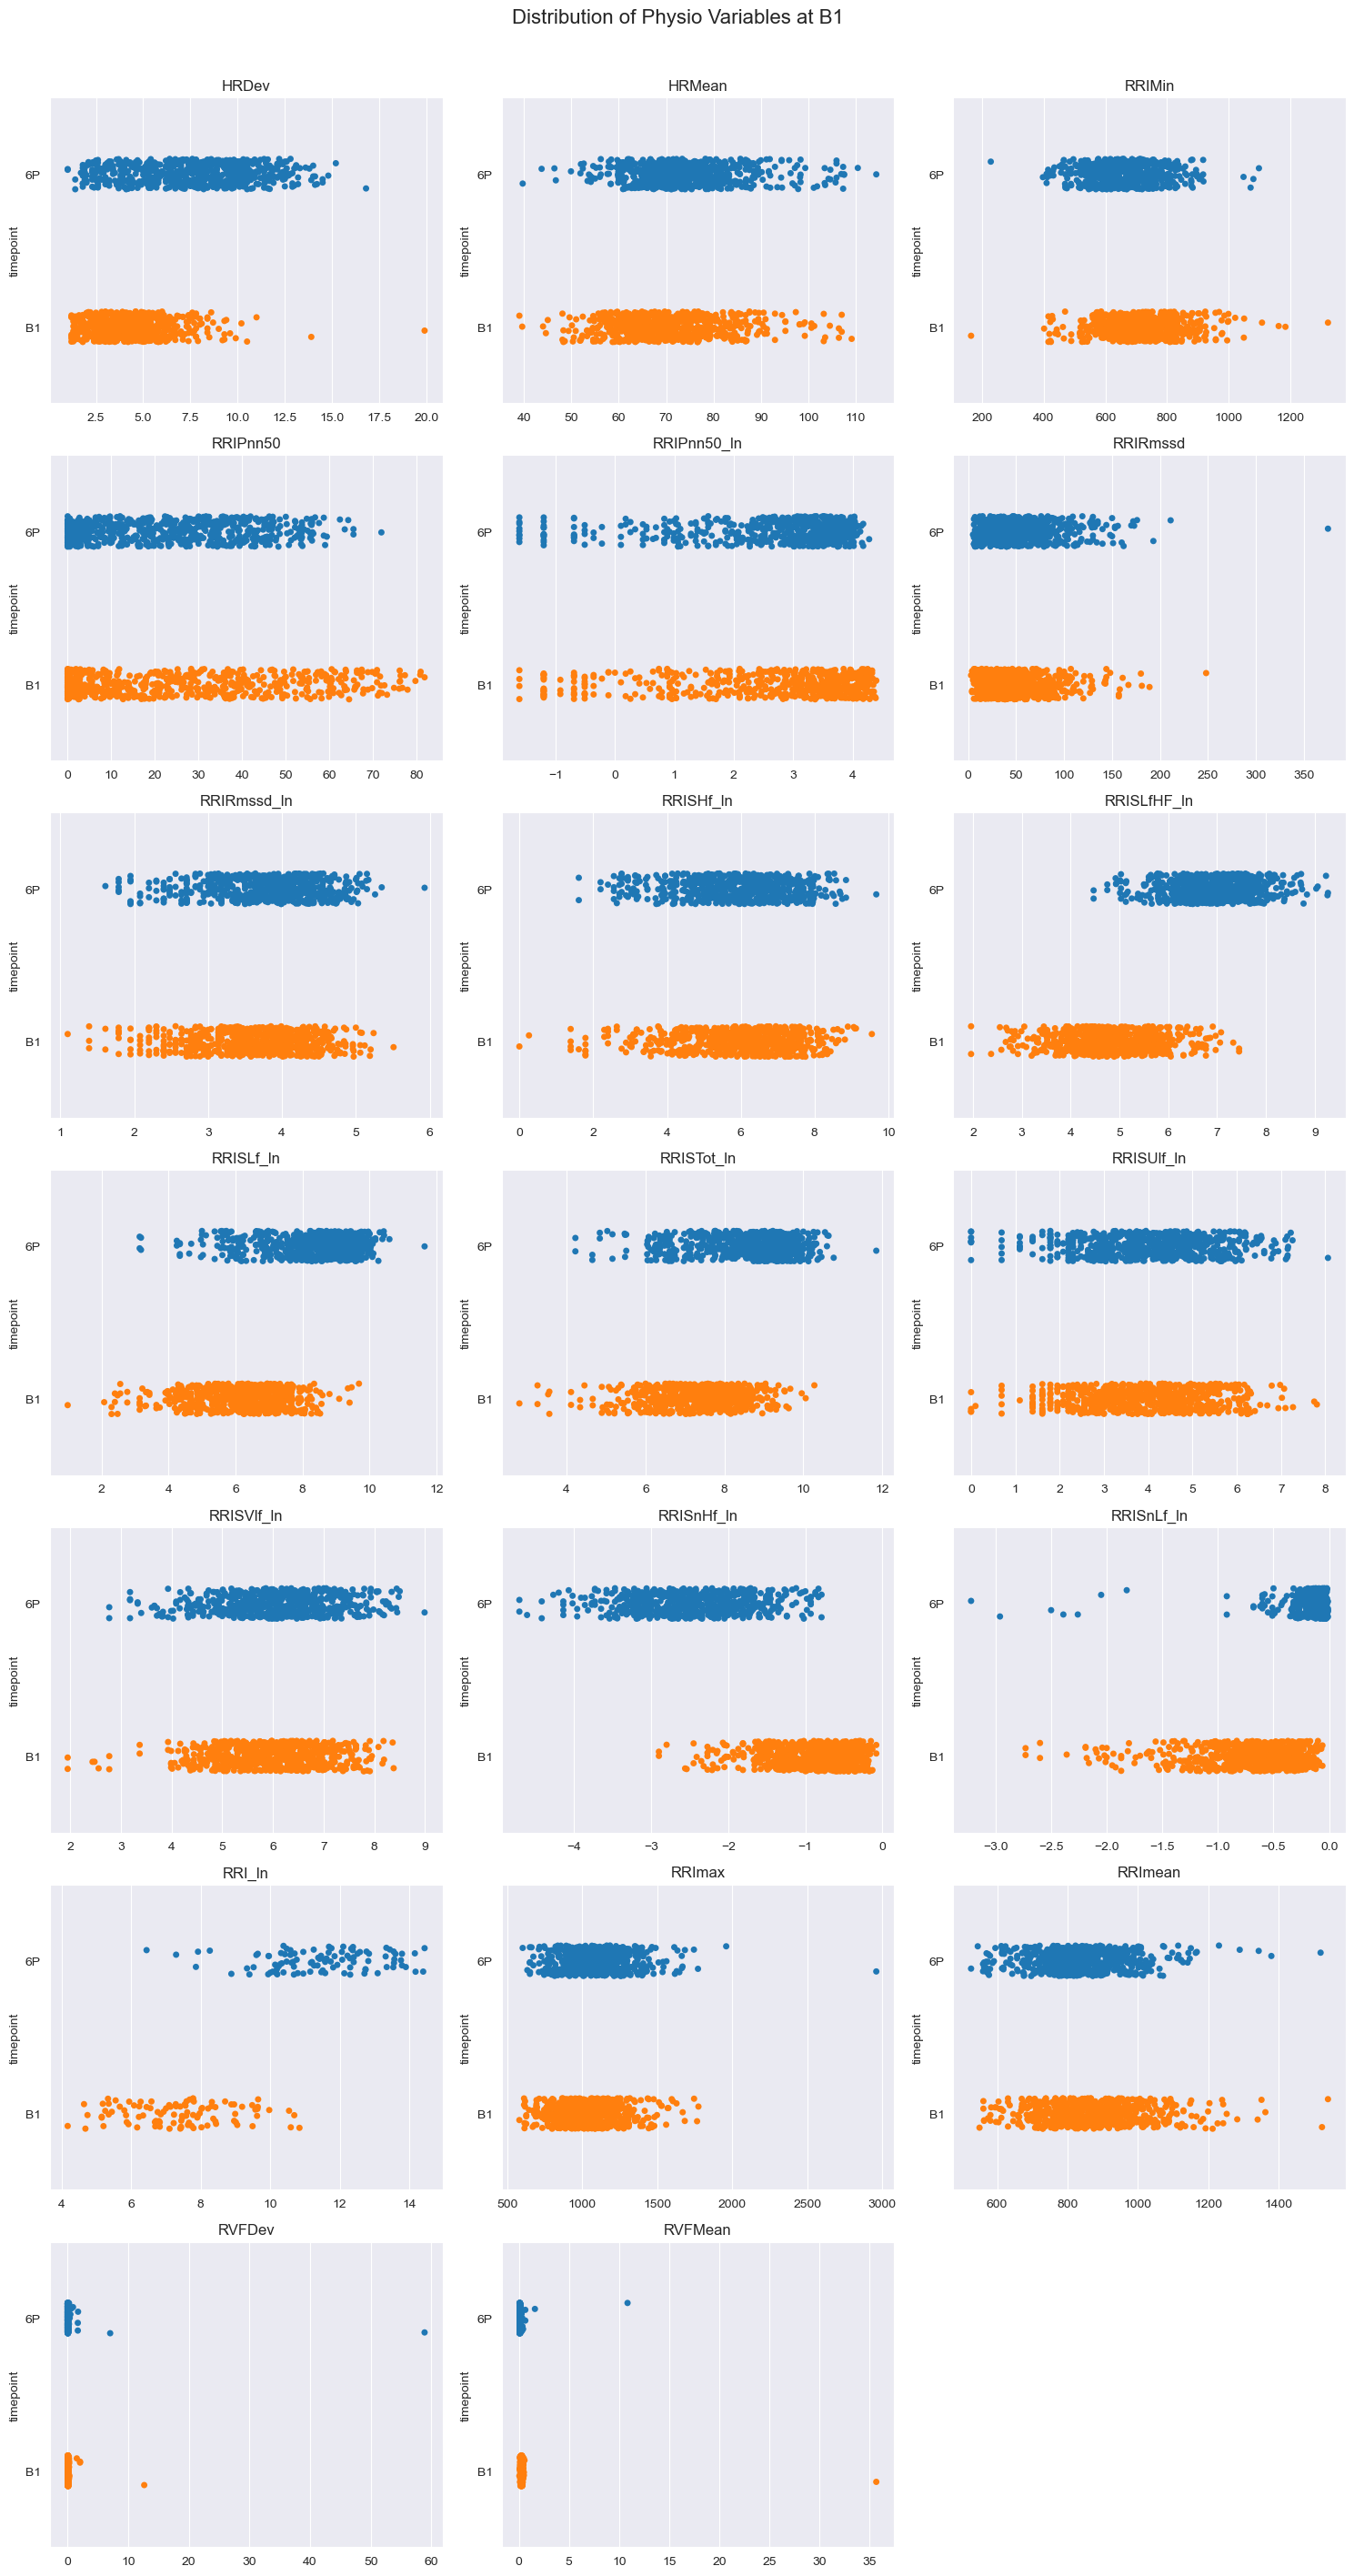

In [149]:

ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.stripplot(data=physio_demo_df, y='timepoint', x=var, hue='timepoint', ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    # axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

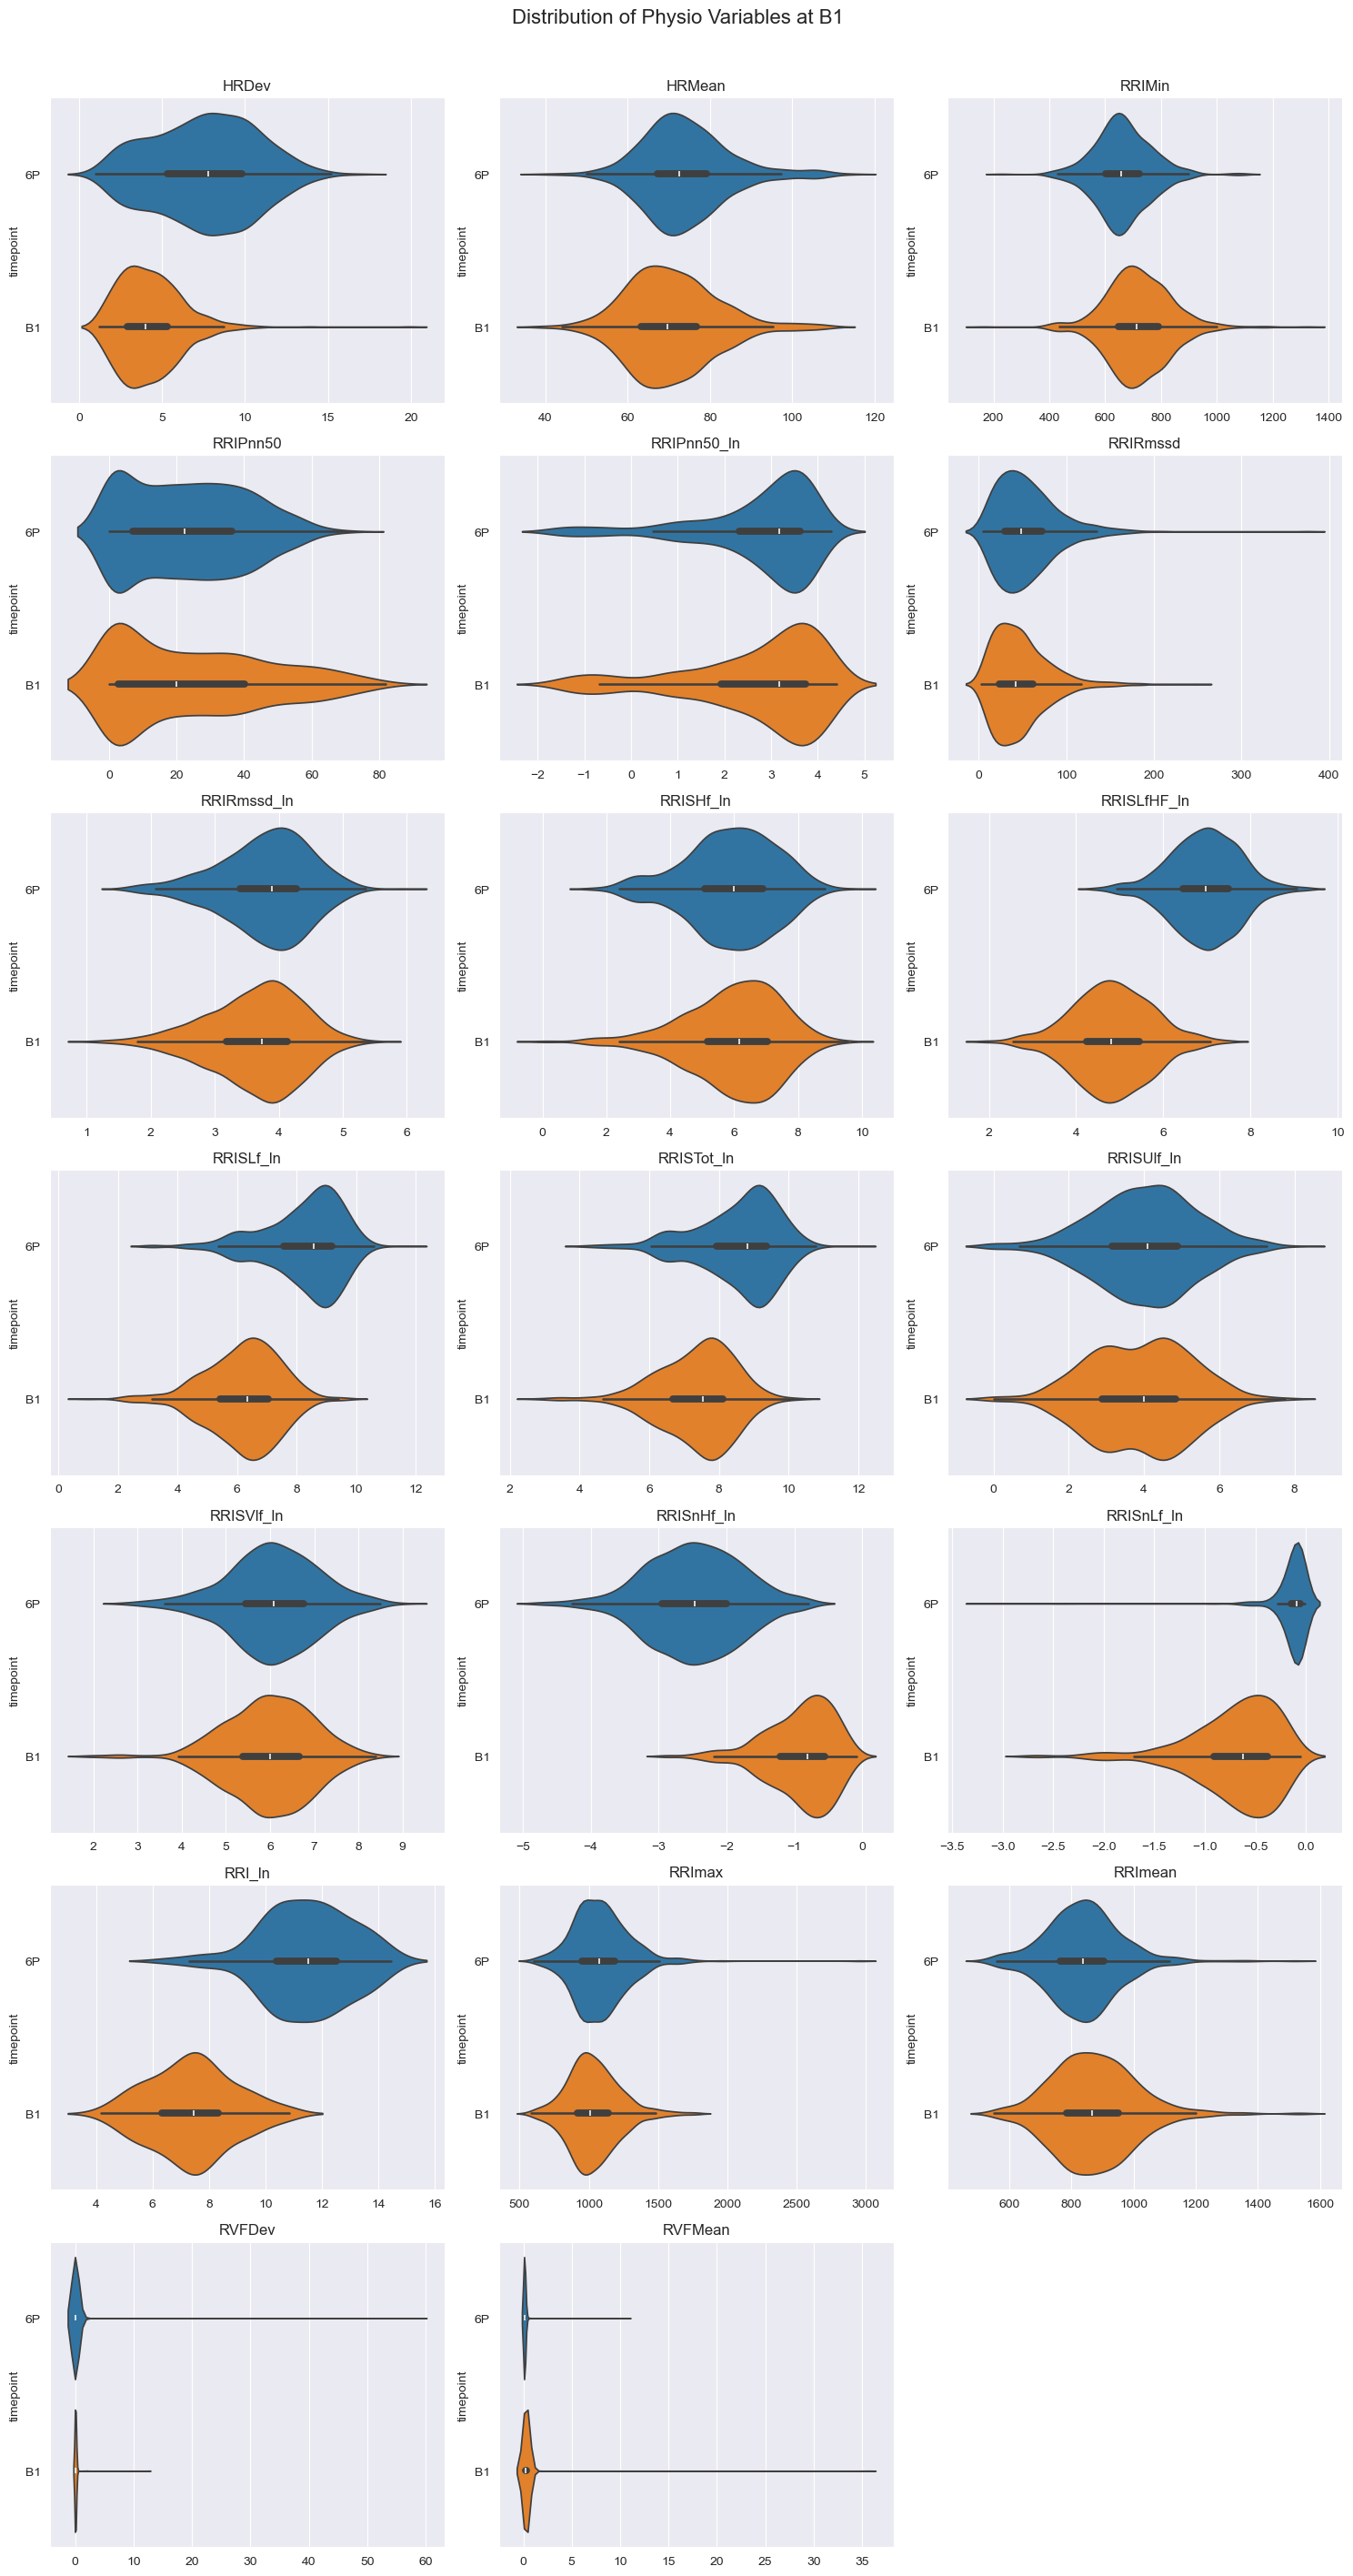

In [150]:

ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.violinplot(data=physio_demo_df, y='timepoint', x=var, hue='timepoint', ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    # axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [151]:
physio_df_b1[all_physio_vars].columns

Index(['RRIMin', 'RRImax', 'RRImean', 'RRIRmssd', 'RRIPnn50', 'RRISTot',
       'RRISUlf', 'RRISVlf', 'RRISLf', 'RRISHf', 'RRISLfHF', 'RRISnLf',
       'RRISnHf', 'RRI', 'RRISTot_ln', 'RRISUlf_ln', 'RRISVlf_ln', 'RRISLf_ln',
       'RRISHf_ln', 'RRISLfHF_ln', 'RRISnLf_ln', 'RRISnHf_ln', 'RRI_ln',
       'RRIRmssd_ln', 'RRIPnn50_ln', 'RVFMean', 'RVFDev'],
      dtype='object')

In [152]:
normality_results = []

for var in main_physio_vars:
    result = pg.normality(physio_df_b1[var].dropna(), method='shapiro').round(3)
    result.insert(0, 'variable', var)
    normality_results.append(result)

normality_results_df = pd.concat(normality_results, ignore_index=True)
normality_results_df = pd.DataFrame(normality_results_df)
normality_results_df['Reject_null'] = normality_results_df['pval'].map(lambda x: 'Yes' if x < 0.05 else 'No')

normality_results_df


,variable,W,pval,normal,Reject_null
0,HRDev,0.922,0.000,False,Yes
1,HRMean,0.979,0.000,False,Yes
2,RRIMin,0.977,0.000,False,Yes
3,RRIPnn50,0.902,0.000,False,Yes
4,RRIPnn50_ln,0.859,0.000,False,Yes
5,RRIRmssd,0.894,0.000,False,Yes
6,RRIRmssd_ln,0.981,0.000,False,Yes
7,RRISHf_ln,0.968,0.000,False,Yes
8,RRISLfHF_ln,0.998,0.522,True,No
9,RRISLf_ln,0.979,0.000,False,Yes


### **Normality Summary:** 

**Date written/updated:** 4-30-26

Based on Shapiro-Wilke test of normality, the following physiology variables are normally distributed:
- RRISLfHF_ln
- RRI_ln

all other variables in 'main_physio_vars' are considered to have non-normal data distribution.

**Moving Forward:**

Consider whether or not further data cleaning, modification needs to occur (e.g., alternative transformation?) and which tests to run (paramatric vs. non-parametric) based on the research questions/hypotheses. 


### **T-tests**

**Note:**

Based on previous descriptive statistics and tests of normality, determine which variables should be tested with parametric vs. non-paremetric tests
- e.g., Dependent samples T-test vs. Wilcoxon signed-rank test

In [153]:
## Running pairwise t-tests for each main physiological variable across timepoints, with Bonferroni correction for multiple comparisons.
ttest_results = []

for var in main_physio_vars:
    result = pg.pairwise_tests(data=physio_demo_df, dv=var, between='timepoint', subject = 'ID6', padjust='none').round(3)
    result.insert(0, 'variable', var)
    ttest_results.append(result)

ttest_results_df = pd.concat(ttest_results, ignore_index=True)
ttest_results_df = pd.DataFrame(ttest_results_df)
ttest_results_df['Reject_null'] = ttest_results_df['p-unc'].map(lambda p: 'Yes' if p < 0.05 else 'No')

ttest_results_df


,variable,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges,Reject_null
0,HRDev,timepoint,6P,B1,False,True,23.534,1346.000,two-sided,0.000,9.149e+98,1.281,Yes
1,HRMean,timepoint,6P,B1,False,True,5.660,1346.000,two-sided,0.000,3.914e+05,0.308,Yes
2,RRIMin,timepoint,6P,B1,False,True,-9.281,1346.000,two-sided,0.000,5.653e+16,-0.505,Yes
3,RRIPnn50,timepoint,6P,B1,False,True,-1.412,1346.000,two-sided,0.158,0.164,-0.077,No
4,RRIPnn50_ln,timepoint,6P,B1,False,True,0.791,1196.582,two-sided,0.429,0.087,0.045,No
5,RRIRmssd,timepoint,6P,B1,False,True,3.886,1346.000,two-sided,0.000,103.102,0.212,Yes
6,RRIRmssd_ln,timepoint,6P,B1,False,True,4.123,1346.000,two-sided,0.000,260.881,0.224,Yes
7,RRISHf_ln,timepoint,6P,B1,False,True,-0.998,1346.000,two-sided,0.318,0.1,-0.054,No
8,RRISLfHF_ln,timepoint,6P,B1,False,True,45.974,1346.000,two-sided,0.000,6.025e+273,2.503,Yes
9,RRISLf_ln,timepoint,6P,B1,False,True,29.107,1346.000,two-sided,0.000,6.586e+140,1.585,Yes


In [154]:
## Post-hoc Games-Howell test for pairwise comparisons across timepoints for each main physiological variable, which does not assume equal variances or sample sizes.

games_howell_results = []

for var in main_physio_vars:
    result = pg.pairwise_gameshowell(data=physio_demo_df, dv=var, between='timepoint').round(3)
    result.insert(0, 'variable', var)
    games_howell_results.append(result)
    games_howell_results_df = pd.concat(games_howell_results, ignore_index=True)
    games_howell_results_df['Reject_null'] = games_howell_results_df['pval'].map(lambda p: 'Yes' if p < 0.05 else 'No')

games_howell_results_df = pd.DataFrame(games_howell_results_df)

games_howell_results_df




,variable,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges,Reject_null
0,HRDev,6P,B1,7.555,4.254,3.301,0.140,23.534,1124.892,0.000,1.281,Yes
1,HRMean,6P,B1,73.943,70.619,3.324,0.587,5.660,1344.991,0.000,0.308,Yes
2,RRIMin,6P,B1,662.941,718.148,-55.208,5.949,-9.281,1322.367,0.000,-0.505,Yes
3,RRIPnn50,6P,B1,23.082,24.620,-1.538,1.089,-1.412,1260.393,0.158,-0.077,No
4,RRIPnn50_ln,6P,B1,2.721,2.658,0.064,0.081,0.791,1196.582,0.429,0.045,No
5,RRIRmssd,6P,B1,55.019,47.766,7.254,1.867,3.886,1328.538,0.000,0.212,Yes
6,RRIRmssd_ln,6P,B1,3.792,3.632,0.160,0.039,4.123,1343.380,0.000,0.224,Yes
7,RRISHf_ln,6P,B1,5.892,5.970,-0.079,0.079,-0.998,1341.458,0.318,-0.054,No
8,RRISLfHF_ln,6P,B1,6.950,4.828,2.122,0.046,45.974,1321.706,0.000,2.503,Yes
9,RRISLf_ln,6P,B1,8.236,6.193,2.043,0.070,29.107,1342.115,0.000,1.585,Yes


In [155]:
ttest_posthoc_results_df = pd.merge (ttest_results_df, games_howell_results_df, on=['variable', 'A', 'B', 'T', 'Reject_null'], how='left', suffixes=('_ttest', '_gameshowell'))

ttest_posthoc_results_df

,variable,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges_ttest,Reject_null,mean(A),mean(B),diff,se,df,pval,hedges_gameshowell
0,HRDev,timepoint,6P,B1,False,True,23.534,1346.000,two-sided,0.000,9.149e+98,1.281,Yes,7.555,4.254,3.301,0.140,1124.892,0.000,1.281
1,HRMean,timepoint,6P,B1,False,True,5.660,1346.000,two-sided,0.000,3.914e+05,0.308,Yes,73.943,70.619,3.324,0.587,1344.991,0.000,0.308
2,RRIMin,timepoint,6P,B1,False,True,-9.281,1346.000,two-sided,0.000,5.653e+16,-0.505,Yes,662.941,718.148,-55.208,5.949,1322.367,0.000,-0.505
3,RRIPnn50,timepoint,6P,B1,False,True,-1.412,1346.000,two-sided,0.158,0.164,-0.077,No,23.082,24.620,-1.538,1.089,1260.393,0.158,-0.077
4,RRIPnn50_ln,timepoint,6P,B1,False,True,0.791,1196.582,two-sided,0.429,0.087,0.045,No,2.721,2.658,0.064,0.081,1196.582,0.429,0.045
5,RRIRmssd,timepoint,6P,B1,False,True,3.886,1346.000,two-sided,0.000,103.102,0.212,Yes,55.019,47.766,7.254,1.867,1328.538,0.000,0.212
6,RRIRmssd_ln,timepoint,6P,B1,False,True,4.123,1346.000,two-sided,0.000,260.881,0.224,Yes,3.792,3.632,0.160,0.039,1343.380,0.000,0.224
7,RRISHf_ln,timepoint,6P,B1,False,True,-0.998,1346.000,two-sided,0.318,0.1,-0.054,No,5.892,5.970,-0.079,0.079,1341.458,0.318,-0.054
8,RRISLfHF_ln,timepoint,6P,B1,False,True,45.974,1346.000,two-sided,0.000,6.025e+273,2.503,Yes,6.950,4.828,2.122,0.046,1321.706,0.000,2.503
9,RRISLf_ln,timepoint,6P,B1,False,True,29.107,1346.000,two-sided,0.000,6.586e+140,1.585,Yes,8.236,6.193,2.043,0.070,1342.115,0.000,1.585


In [156]:
## Can export results of statistics to Excel for easier review and sharing with research team.

# # ttest_posthoc_results_df.to_excel('stats_test.xlsx')

In [157]:
import pandas as pd
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import scipy.stats as stats

# Keep only needed rows
temp = physio_demo_df[physio_demo_df['timepoint'].isin(['B1', '6P'])]

wide = temp.pivot_table(
    index='ID6',
    columns='timepoint',
    values='HRMean',
    aggfunc='mean',
    observed=False
)

wide = wide.dropna(subset=['B1', '6P'])

wide['diff'] = wide['6P'] - wide['B1']

stat, p = shapiro(wide['diff'])

print(f"Shapiro-Wilk W={stat:.3f}, p={p:.4f}")

Shapiro-Wilk W=0.967, p=0.0000


In [158]:
test_df = physio_demo_df.copy()

test_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,152000,VT1,B1,689,1066,838,39,19.7,53,4.7,...,5.22,5.87,6.35,6.09,4.86,-0.84,NaN,7.29,3.66,2.98
1,152000,VT1,6P,662,1207,882,93,40.5,133,10.5,...,3.18,5.65,9.52,7.88,6.24,-1.82,NaN,14.16,4.53,3.70
2,152002,VT1,B1,673,992,850,33,10.6,57,3.9,...,5.53,6.48,6.56,5.44,5.73,-1.41,NaN,10.69,3.50,2.36
3,152002,VT1,6P,617,1118,878,87,45.5,148,9.9,...,4.61,6.68,9.78,7.49,6.89,-2.39,NaN,14.40,4.47,3.82
4,152004,VT1,B1,702,961,814,24,1.4,38,2.9,...,2.20,5.45,5.91,5.27,5.25,-1.08,NaN,8.36,3.18,0.34


In [159]:
## Create loop for assessing normality of each main phyiso variable. 

for var in main_physio_vars:
    globals()[f'{var}_pivot'] = physio_demo_df.pivot_table(
        index='ID6',
        columns='timepoint',
        values=var,
        aggfunc='mean',
        observed=False
    ).dropna(subset=['B1', '6P'])
    globals()[f'{var}_pivot']['diff'] = globals()[f'{var}_pivot']['6P'] - globals()[f'{var}_pivot']['B1']





In [160]:
## Create loop for assessing normality of each main phyiso variable. 
Normality_test_results = []

for var in main_physio_vars:
    globals()[f'{var}_pivot'] = physio_demo_df.pivot_table(
        index='ID6',
        columns='timepoint',
        values=var,
        aggfunc='mean',
        observed=False
    ).dropna(subset=['B1', '6P'])
    globals()[f'{var}_pivot']['diff'] = globals()[f'{var}_pivot']['6P'] - globals()[f'{var}_pivot']['B1']
    stat, p = shapiro(globals()[f'{var}_pivot']['diff'])
    # print(f"{var}: Shapiro-Wilk W={stat:.3f}, p={p:.4f}")
    Normality_test_results.append({
        'variable': var,
        'W_statistic': stat,
        'p_value': p,
        'Reject_null': 'Yes' if p < 0.05 else 'No',
        'Note': 'Non-normal distribution' if p < 0.05 else 'Normal distribution'
    })

Normality_test_results_df = pd.DataFrame(Normality_test_results)

Normality_test_results_df





,variable,W_statistic,p_value,Reject_null,Note
0,HRDev,0.958554,8.999481e-12,Yes,Non-normal distribution
1,HRMean,0.967333,3.993552e-10,Yes,Non-normal distribution
2,RRIMin,0.886989,2.857366e-20,Yes,Non-normal distribution
3,RRIPnn50,0.983056,2.605537e-06,Yes,Non-normal distribution
4,RRIPnn50_ln,0.928534,2.478051e-15,Yes,Non-normal distribution
5,RRIRmssd,0.922248,8.304607e-17,Yes,Non-normal distribution
6,RRIRmssd_ln,0.990546,8.342907e-04,Yes,Non-normal distribution
7,RRISHf_ln,0.981822,1.143337e-06,Yes,Non-normal distribution
8,RRISLfHF_ln,0.995668,1.048369e-01,No,Normal distribution
9,RRISLf_ln,0.981048,6.920419e-07,Yes,Non-normal distribution


### Homogeneity of Variance tests

In [161]:
## Create loop for assessing normality of each main phyiso variable. 
homoscedasticity_test_results = []

for var in main_physio_vars:
    result = pg.homoscedasticity(data=physio_demo_df, dv=var, group='timepoint', method='levene')
    homoscedasticity_test_results.append({
        'variable': var,
        'W_statistic': result['W'].iloc[0],
        'p_value': result['pval'].iloc[0],
        'Reject_null': 'Yes' if result['pval'].iloc[0] < 0.05 else 'No',
        'Note': 'Unequal variances' if result['pval'].iloc[0] < 0.05 else 'Equal variances'
    })

    
    
homoscedasticity_test_results_df = pd.DataFrame(homoscedasticity_test_results)

homoscedasticity_test_results_df


,variable,W_statistic,p_value,Reject_null,Note
0,HRDev,166.385724,5.603481e-36,Yes,Unequal variances
1,HRMean,1.766831,1.840001e-01,No,Equal variances
2,RRIMin,7.914401,4.975577e-03,Yes,Unequal variances
3,RRIPnn50,49.795099,2.723866e-12,Yes,Unequal variances
4,RRIPnn50_ln,NaN,NaN,No,Equal variances
5,RRIRmssd,3.728790,5.369190e-02,No,Equal variances
6,RRIRmssd_ln,1.257070,2.624063e-01,No,Equal variances
7,RRISHf_ln,0.475707,4.904923e-01,No,Equal variances
8,RRISLfHF_ln,10.606040,1.155268e-03,Yes,Unequal variances
9,RRISLf_ln,0.491240,4.834956e-01,No,Equal variances


In [162]:
normality_homoscedasticity_df = pd.merge(Normality_test_results_df, homoscedasticity_test_results_df, on='variable', how='outer', suffixes=('_norm', '_homo'))

normality_homoscedasticity_df

,variable,W_statistic_norm,p_value_norm,Reject_null_norm,Note_norm,W_statistic_homo,p_value_homo,Reject_null_homo,Note_homo
0,HRDev,0.958554,8.999481e-12,Yes,Non-normal distribution,166.385724,5.603481e-36,Yes,Unequal variances
1,HRMean,0.967333,3.993552e-10,Yes,Non-normal distribution,1.766831,1.840001e-01,No,Equal variances
2,RRIMin,0.886989,2.857366e-20,Yes,Non-normal distribution,7.914401,4.975577e-03,Yes,Unequal variances
3,RRIPnn50,0.983056,2.605537e-06,Yes,Non-normal distribution,49.795099,2.723866e-12,Yes,Unequal variances
4,RRIPnn50_ln,0.928534,2.478051e-15,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
5,RRIRmssd,0.922248,8.304607e-17,Yes,Non-normal distribution,3.728790,5.369190e-02,No,Equal variances
6,RRIRmssd_ln,0.990546,8.342907e-04,Yes,Non-normal distribution,1.257070,2.624063e-01,No,Equal variances
7,RRISHf_ln,0.981822,1.143337e-06,Yes,Non-normal distribution,0.475707,4.904923e-01,No,Equal variances
8,RRISLfHF_ln,0.995668,1.048369e-01,No,Normal distribution,10.606040,1.155268e-03,Yes,Unequal variances
9,RRISLf_ln,0.981048,6.920419e-07,Yes,Non-normal distribution,0.491240,4.834956e-01,No,Equal variances


### **Factorial ANCOVAs**

**Dependent Variables:** 
- HRV measures
- Respiratory measures

**Independent Variables:**
- Time (categorical, 2 levels) | B1, 6P
- Sex (categoricla, 2 levels) | Male, Female
- Age (continuous)
- Height (continuous)
- Weight (continuous)
- BMI (continuous)
- BMI_cat (categorical, 6 levels) | Underweight, Normal weight, overweight, obese class 1, obese class 2, obese class 3
- Race (categorical, 6 levels) | American Indian/Native Alaskan, Asian, Black/African American, Native Hawaiian/Pacific Islander, White, Other
- Ethnicity (categorical ?? levels) | skip and use Hispanic
- Hispanic (categorical, 2 levels) | Yes, No

**Initial Analyses Plan:**
- Factorial ANCOVA: Time*BMI_cat (age as covariate)
- Factorial ANCOVA: Time*Sex (age and/or bmi as covariate)
- Factorial ANCOVA: Time*Race (age and/or bmi as covariate)
- Factorial ANCOVA: Time*Ethnicity (age and/or bmi as covariate)

In [163]:
## mixed_anova test

### change these to change the analysis between notebook cells
DV = 'HRMean'
within_var = 'timepoint'
between_var = 'bmi_cat' 

result = pg.mixed_anova(data=physio_demo_df, dv=DV, within=within_var, between=between_var, subject='ID6',
               correction='auto', effsize='np2'
               ).round(3)
print("mixed_anova results:")
display(result)

#### post-hoc test

post_hoc_result = pg.pairwise_tests(data=physio_demo_df, dv=DV, within=within_var, between=between_var, subject='ID6',
                                     marginal=True,
                                     correction='auto',
                                     padjust= 'bonf',
                                     ).round(3).sort_values(by='p-unc', ascending=True)

print("Post-hoc test results:")
display(post_hoc_result)

mixed_anova results:


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,bmi_cat,616.018,3,333,205.339,0.919,0.432,0.008,NaN
1,timepoint,3329.383,1,333,3329.383,151.194,0.000,0.312,1.0
2,Interaction,165.057,3,333,55.019,2.499,0.060,0.022,NaN


Post-hoc test results:


,Contrast,timepoint,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,timepoint,-,6P,B1,True,True,12.215,336.000,two-sided,0.000,NaN,NaN,2.533e+25,0.401
16,timepoint * bmi_cat,B1,Underweight,Overweight,False,True,1.925,12.306,two-sided,0.078,0.932,bonf,1.339,0.616
13,timepoint * bmi_cat,B1,Healthy weight,Underweight,False,True,-1.724,11.095,two-sided,0.112,1.000,bonf,0.994,-0.553
4,bmi_cat,-,Underweight,Overweight,False,True,1.647,12.898,two-sided,0.124,0.742,bonf,0.904,0.483
17,timepoint * bmi_cat,B1,Underweight,Obese,False,True,1.416,14.318,two-sided,0.178,1.000,bonf,0.706,0.518
5,bmi_cat,-,Underweight,Obese,False,True,1.377,14.852,two-sided,0.189,1.000,bonf,0.677,0.488
1,bmi_cat,-,Healthy weight,Underweight,False,True,-1.331,11.343,two-sided,0.209,1.000,bonf,0.614,-0.391
11,timepoint * bmi_cat,6P,Underweight,Obese,False,True,1.151,15.082,two-sided,0.268,1.000,bonf,0.544,0.403
10,timepoint * bmi_cat,6P,Underweight,Overweight,False,True,1.110,13.396,two-sided,0.287,1.000,bonf,0.503,0.306
9,timepoint * bmi_cat,6P,Healthy weight,Obese,False,True,1.003,65.903,two-sided,0.319,1.000,bonf,0.294,0.153


In [164]:
physio_demo_df.groupby('bmi_cat', observed=True).size().reset_index(name='count')

,bmi_cat,count
0,Healthy weight,454
1,Underweight,26
2,Overweight,242
3,Obese,128


### Linear Mixed Models

(Placeholder for now)

- DV ~ Fixed Effects | (random effect)

**example:** 

- DV ~ time * age * sex * race * bmi | (ID6)



In [165]:
import statsmodels.formula.api as smf

In [188]:
physio_demo_df['timepoint'] = pd.Categorical(physio_demo_df['timepoint'], categories=['B1', '6P'], ordered=True)

In [189]:
### Note: 5/14/26, revise LMMs here to make sure they're working for other vars
DV = 'HRMean'
within_var = 'timepoint'
between_var = 'bmi_cat'

fildered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)


model = smf.mixedlm(
    formula=f'{DV} ~ C({within_var}, Treatment("B1")) + C({between_var})',
    data=fildered_df,
    groups=fildered_df['ID6']
)

result = model.fit()
print(result.summary())

                     Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        HRMean    
No. Observations:          850            Method:                    REML      
No. Groups:                337            Scale:                     16.7167   
Min. group size:           2              Log-Likelihood:            -2864.1609
Max. group size:           4              Converged:                 Yes       
Mean group size:           2.5                                                 
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                            71.269    0.785 90.829 0.000 69.731 72.806
C(timepoint, Treatment("B1"))[T.6P]   3.694    0.280 13.172 0.000  3.145  4.244
C(bmi_cat)[T.Underweight]             4.117    3.293  1.250 0

In [185]:
DV = 'HRMean'
within_var = 'timepoint'
between_var = 'bmi_cat'

fildered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)

# Fit mixed LMM with random intercept per subject
model = smf.mixedlm(
    formula=f'{DV} ~ C({within_var}, Treatment("B1")) * C({between_var})',
    data=fildered_df,
    groups=fildered_df['ID6']  # random intercept per subject
)

result = model.fit(reml=True)  # REML standard for LMM variance estimation
print(result.summary())


                                  Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 HRMean    
No. Observations:                  850                     Method:                             REML      
No. Groups:                        337                     Scale:                              16.4064   
Min. group size:                   2                       Log-Likelihood:                     -2855.2973
Max. group size:                   4                       Converged:                          Yes       
Mean group size:                   2.5                                                                   
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

In [191]:
## re-wrote the above LMM to not explicitly call categorical vars or the reference point

DV = 'HRMean'
within_var = 'timepoint'
between_var = 'bmi_cat'

fildered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)
### fildered_df['timepoint'] = pd.Categorical(fildered_df['timepoint'], categories=['B1', '6P'], ordered=True) ## can remove I think

# Fit mixed LMM with random intercept per subject
model = smf.mixedlm(
    formula=f'{DV} ~ {within_var} * {between_var}',
    data=fildered_df,
    groups=fildered_df['ID6']  # random intercept per subject
)

result = model.fit(reml=True)  # REML standard for LMM variance estimation
print(result.summary())


                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         HRMean    
No. Observations:           850             Method:                     REML      
No. Groups:                 337             Scale:                      16.4064   
Min. group size:            2               Log-Likelihood:             -2855.2973
Max. group size:            4               Converged:                  Yes       
Mean group size:            2.5                                                   
----------------------------------------------------------------------------------
                                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                               70.933    0.795 89.223 0.000 69.375 72.492
timepoint[T.6P]                          4.365    0.380 11.480 0.000  3.620  5.110
bmi_cat[T.Underweight]     

In [166]:
physio_demo_df['bmi_cat'].unique()

['Overweight', 'Healthy weight', 'Obese', 'Underweight', NaN]
Categories (4, object): ['Healthy weight' < 'Underweight' < 'Overweight' < 'Obese']

#### Interpreting the LMM output:

- Intercept = 68.814 --> average HR at B1 timepoint for the reference bmi_cat group (healthy weight)
- timepoint(T.6P) = 8.856 --> for healthy weight individual, HR increased by 8.856 bpm from B1 to 6P
- bmi_cat[T.Underweight] = 25.080 --> underweight individuals' avg HR was ~25 bpm higher than the reference group at the reference timepoint... (repeat for other categories)

- timepoint[6P]:bmi_cat[T.underweight] = -15.726 p=0.001 --> the change in avg HR from B1 to 6P timepoint was 15.726 units smaller in underweight vs. healthy weight (reference) individuals
  - since the reference group gained 8.856 bpm from B1 to 6P and the underweight group had a -15.726 smaller change than the reference group, 8.856 - 15.726 = -6.87 bpm, meaning the underweight group had a decrease in their average HR from B1 to 6P (can verify with visual)

In [ ]:
fig, ax = plt.subplots(1,2, sharey=True, figsize=(15,6))

ax1 = sns.pointplot(data=physio_demo_df, x='timepoint', y='HRMean',
              dodge= True, err_kws=({'lw':1.2}), capsize=0.05,
              ax=ax[0])
ax1.set_title('HRMean B1 to 6P', fontsize=20)
#### Second Plot
ax2 = sns.pointplot(data=physio_demo_df, x='timepoint', y='HRMean', hue='bmi_cat',
              dodge= True, err_kws=({'lw':1.2}), capsize=0.05,
              ax=ax[1])

ax2.set_title('HRMean B1 to 6P by BMI category', fontsize=20)

plt.legend(title='BMI category', bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.tight_layout()
plt.show()
### Lines are staggered for better visibility.

## Individual Study (database) Exploratory Data Analysis

In [ ]:
physio_demo_df.to_excel("physio_demo_data_cleaned_04302026.xlsx", index=False)

## Placing data export here for full df as everything is cleaned before looking at individual DB datasets.

### Create individual dfs for each database to explore each dataset's characteristics

In [ ]:
## Loop through physio_demo_df to create new sub_dfs (e.g., baa_df)

dataset_names = list(physio_demo_df['from_study'].unique())

dataset_names

## noting that VT3 isn't in here yet, nor is Athlete

In [ ]:
## get the list of unique dataset names from the 'from_study' column in physio_demo_df, then loop through that list to create new dataframes for each dataset (e.g., baa_df, etc.)
dataset_names = list(physio_demo_df['from_study'].unique())
### missing VT3 for some reason
print(dataset_names)


In [ ]:
## Run the loop to create the new dataframes for each dataset (e.g., baa_df, etc.)

for dataset in dataset_names:
    globals()[f"{dataset}_df"] = physio_demo_df[physio_demo_df['from_study'] == dataset].copy().reset_index(drop=True)

### BAA data

In [ ]:
BAA_df.head()

In [ ]:
baa_missing_values_df = pd.DataFrame({
    'count': BAA_df.isnull().sum(),
    'percent': (BAA_df.isnull().sum() / len(BAA_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(baa_missing_values_df)

In [ ]:
baa_missing_cols_only = baa_missing_values_df[baa_missing_values_df['percent']>0].copy().reset_index(drop=True)

baa_missing_cols_only

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=baa_missing_cols_only['count'], y=baa_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: BAA', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=baa_missing_cols_only['percent'], y=baa_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: BAA', fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
### BAA demographics

BAA_b1_df = BAA_df[BAA_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

BAA_b1_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=BAA_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: BAA B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=BAA_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: BAA B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,10))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=baa_missing_values_df['count'], y=baa_missing_values_df['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: BAA', fontsize=25)
ax1.grid(True)

### Plot 2- Percent missing by variable
ax2= sns.barplot(x=baa_missing_values_df['percent'], y=baa_missing_values_df['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: BAA', fontsize=25)

ax2.grid(True)
plt.tight_layout()
plt.show()

### CGE data

In [ ]:
CGE_df.head()

In [ ]:
list(CGE_df.columns)

In [ ]:
CGE_df.shape

In [ ]:
CGE_df.info()

In [ ]:
CGE_missing_values_df = pd.DataFrame({
    "count": CGE_df.isnull().sum(),
    "percent": (CGE_df.isnull().sum() / len(CGE_df)) * 100
}).reset_index().rename(columns={'index': 'column'})


print(CGE_missing_values_df)

In [ ]:
CGE_missing_values_only = CGE_missing_values_df[CGE_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

CGE_missing_values_only.head()

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=CGE_missing_values_only['count'], y=CGE_missing_values_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: CGE', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=CGE_missing_values_only['percent'], y=CGE_missing_values_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: CGE', fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
CGE_b1_df = CGE_df[CGE_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

CGE_b1_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=CGE_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: CGE B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=CGE_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: CGE B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Stress_pic data

In [ ]:
stress_pic_df.head()

In [ ]:
stress_pic_df.shape

In [ ]:
stress_pic_df_missing_values_df = pd.DataFrame({
    'count': stress_pic_df.isnull().sum(),
    'percent': (stress_pic_df.isnull().sum() / len(stress_pic_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(stress_pic_df_missing_values_df)

In [ ]:
stress_pic_df_missing_cols_only = stress_pic_df_missing_values_df[stress_pic_df_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

stress_pic_df_missing_cols_only

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=stress_pic_df_missing_cols_only['count'], y=stress_pic_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: stress_pic', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=stress_pic_df_missing_cols_only['percent'], y=stress_pic_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: stress_pic', fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
stress_pic_df_b1 = stress_pic_df[stress_pic_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

stress_pic_df_b1.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_pic_df_b1, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: stress_pic B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_pic_df_b1, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: stress_pic B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Stress_suppl data

In [ ]:
stress_suppl_df.head()

In [ ]:
stress_suppl_df.shape

In [ ]:
stress_suppl_missing_values_df = pd.DataFrame({
    'count': stress_suppl_df.isna().sum(),
    'percent': stress_suppl_df.isna().sum() / len(stress_suppl_df) * 100
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

stress_suppl_missing_values_df.head()

In [ ]:
stress_supple_missing_cols_only = stress_suppl_missing_values_df[stress_suppl_missing_values_df['percent']>0].sort_values(by='percent', ascending=True)

stress_supple_missing_cols_only

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=stress_supple_missing_cols_only['count'], y=stress_supple_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: stress_suppl', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=stress_supple_missing_cols_only['percent'], y=stress_supple_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: stress_suppl', fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
stress_suppl_b1_df = stress_suppl_df[stress_suppl_df['timepoint']=='B1'].copy().reset_index(drop=True)

stress_suppl_b1_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_suppl_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: stress_suppl B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_suppl_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: stress_suppl B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Stress_prevention data

In [ ]:
stress_prevention_df.head()

In [ ]:
stress_prevention_df.shape

In [ ]:
stress_prevention_missing_values_df = pd.DataFrame({
    'count': stress_prevention_df.isnull().sum(),
    'percent': (stress_prevention_df.isnull().sum() / len(stress_prevention_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(stress_prevention_missing_values_df)

In [ ]:
stress_prevention_df_missing_cols_only = stress_prevention_missing_values_df[stress_prevention_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

print(stress_prevention_df_missing_cols_only)

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=stress_prevention_df_missing_cols_only['count'], y=stress_prevention_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: stress_prevention', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=stress_prevention_df_missing_cols_only['percent'], y=stress_prevention_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: stress_prevention', fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
stress_prevention_b1_df = stress_prevention_df[stress_prevention_df['timepoint']=='B1'].copy().reset_index(drop=True)

stress_prevention_b1_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_prevention_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: stress_prevention B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=stress_prevention_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: stress_prevention B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### VT1 data

In [ ]:
VT1_df.head()

In [ ]:
VT1_df.shape

In [ ]:
VT1_df['ID6'].unique()

In [ ]:
VT1_df.isna().sum()

In [ ]:
VT1_missing_values_df = pd.DataFrame({
    'count': VT1_df.isnull().sum(),
    'percent': (VT1_df.isnull().sum() / len(VT1_df)) * 100
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

VT1_missing_values_df.head()

In [ ]:
VT1_missing_cols_only = VT1_missing_values_df[VT1_missing_values_df['percent']>0].copy().reset_index(drop=True)

VT1_missing_cols_only.head()

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=VT1_missing_cols_only['count'], y=VT1_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: VT1', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=VT1_missing_cols_only['percent'], y=VT1_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: VT1', fontsize=25)

plt.tight_layout()
plt.show()

### VT2 data

In [ ]:
VT2_df.head()

In [ ]:
VT2_df.shape

In [ ]:
VT2_df_missing_values_df = pd.DataFrame({
    'count': VT2_df.isnull().sum(),
    'percent': (VT2_df.isnull().sum() / len(VT2_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(VT2_df_missing_values_df)

In [ ]:
VT2_df_missing_cols_only = VT2_df_missing_values_df[VT2_df_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

print(VT2_df_missing_cols_only)

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=VT2_df_missing_cols_only['count'], y=VT2_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: VT2', fontsize=25)

### Plot 2- Percent missing by variable
ax2= sns.barplot(x=VT2_df_missing_cols_only['percent'], y=VT2_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)

ax2.set_title('Percent Missing by Variable: VT2', fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
VT1_b1_df = VT1_df[VT1_df['timepoint']=='B1'].copy().reset_index(drop=True)

VT1_b1_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT1_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: VT1 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT1_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: VT1 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
VT2_b1_df = VT2_df[VT2_df['timepoint']=='B1'].copy().reset_index(drop=True)

VT2_b1_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT2_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: VT2 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=VT2_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: VT2 B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### VT3 data

In [ ]:
# sns.set_style('darkgrid')

# fig, ax = plt.subplots(1,2,figsize=(20,8))

# ### Plot 1: Count missing by variable
# ax1= sns.barplot(x=baa_missing_cols_only['count'], y=baa_missing_cols_only['column'], ax=ax[0])

# ax1.set_xlabel('Count', fontsize=20)
# ax1.set_ylabel('Variable', fontsize=20)
# ax1.tick_params(axis='both', labelsize=15)

# ax1.set_title('Count Missing by Variable: BAA', fontsize=25)


# ### Plot 2- Percent missing by variable
# ax2= sns.barplot(x=baa_missing_cols_only['percent'], y=baa_missing_cols_only['column'], ax=ax[1])

# ax2.set_xlabel('Percent', fontsize=20)
# ax2.set_ylabel('Variable', fontsize=20)
# ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='both', labelsize=15)


# ax2.set_title('Percent Missing by Variable: BAA', fontsize=25)

# plt.tight_layout()
# plt.show()

### WTP data

In [ ]:
WTP_df.head()

In [ ]:
WTP_missing_values_df = pd.DataFrame({
    'count': WTP_df.isnull().sum(),
    'percent': (WTP_df.isnull().sum() / len(WTP_df)) * 100 
}).sort_values(by='percent', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

print(WTP_missing_values_df)

In [ ]:
WTP_df_missing_cols_only = WTP_missing_values_df[WTP_missing_values_df['percent'] > 0].copy().sort_values('percent', ascending=False).reset_index(drop=True)

print(WTP_df_missing_cols_only)

In [ ]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,figsize=(20,8))

### Plot 1: Count missing by variable
ax1= sns.barplot(x=WTP_df_missing_cols_only['count'], y=WTP_df_missing_cols_only['column'], ax=ax[0])

ax1.set_xlabel('Count', fontsize=20)
ax1.set_ylabel('Variable', fontsize=20)
ax1.tick_params(axis='both', labelsize=15)

ax1.set_title('Count Missing by Variable: WTP', fontsize=25)


### Plot 2- Percent missing by variable
ax2= sns.barplot(x=WTP_df_missing_cols_only['percent'], y=WTP_df_missing_cols_only['column'], ax=ax[1])

ax2.set_xlabel('Percent', fontsize=20)
ax2.set_ylabel('Variable', fontsize=20)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
ax2.tick_params(axis='both', labelsize=15)


ax2.set_title('Percent Missing by Variable: WTP', fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
WTP_b1_df = WTP_df[WTP_df['timepoint']=='B1'].copy().reset_index(drop=True)

WTP_b1_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=WTP_b1_df, x='age')

ax1.set_xlabel('Age')
ax1.set_title('Age Distribution of Participants: WTP B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax1 = sns.histplot(data=WTP_b1_df, x='sex')

ax1.set_xlabel('Sex')
ax1.set_title('Sex Distribution of Participants: WTP B1', fontsize=20)
ax1.bar_label(ax.containers[0], fontsize=10)
plt.show()

### Athlete

In [ ]:
print('stop')

In [ ]:
asfadfasdf

## marker to 'pause' cells running
## lets me know that everything else above ran